# Imports and Raw Data Processing

In [1]:
# ============================================================
#  Imports
# ============================================================

# --- Standard Libraries ---
import os
import sys
import math
import json
import textwrap
import importlib
from itertools import product as iproduct
from datetime import datetime
from string import Template
from pathlib import Path
from typing import Any, Dict, List, Tuple, Union, Optional
from pprint import pprint
import warnings

# --- Third-Party Libraries ---
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.patches as mpatches
from tabulate import tabulate
from IPython.display import display

# --- Local Modules ---
# Dynamically add `src/` to sys.path (go up two levels)
notebook_dir = Path.cwd()
sys.path.append(str(notebook_dir.parents[2] / "src"))

from nbutils.misc import load_simulation_tree
from nbutils.compile_plot import compile_zne_subplots
from nbutils.zne_plot import plot_zne_result
from nbutils.summarize import summarize_zne_results
from nbutils.export_raw_data_wrapped import export_raw_data_wrapped
from nbutils.master import *

In [2]:
plt.rcParams['font.family'] = 'serif'

In [3]:
# Usage
base_dir = "../experiment14[depol-time-evo-noisy_variousorderzne_tmax_20]/data"
RAW_SIM_DATA = load_simulation_tree(base_dir)
EXACT_SOL: float = -8.566772233505624

In [4]:
RAW_SIM_DATA.keys()

dict_keys(['ZNE', 'VQE', 'VQE_noiseoff'])

In [5]:
RAW_SIM_DATA.keys()

dict_keys(['ZNE', 'VQE', 'VQE_noiseoff'])

Processing ZNE data for plotting.

In [6]:
# ============================================================================
# DATA PROCESSING
# ============================================================================

def _process_vqe_noiseoff(content: dict) -> dict:
    nf_folder = content.get("VQE_noiseoff", {})
    nf_costs  = []
    for k, run in nf_folder.items():
        if not run or "REDUNDANT" in k or "output" not in run:
            continue
        try:
            nf_costs.append(run["output"]["optimized_minimum_cost"][0])
        except (KeyError, IndexError, TypeError):
            continue

    stats = {
        "mean": float(np.mean(nf_costs)) if nf_costs else None,
        "std":  float(np.std(nf_costs))  if nf_costs else None,
    }
    print(f"✅ VQE_noiseoff: {len(nf_costs)} runs aggregated, mean={stats['mean']}")
    return stats


def _extract_single_var_run(run: dict) -> tuple | None:
    """
    Extracts from ZNE-single-var runs.

    JSON structure:
        zne_values.others.sorted_noise
        zne_values.others.sorted_expectation_vals
        zne_values.others.beta_coeffiecients   (sic — typo in source JSON)
        zne_values.others.cost_richardson_zne
        zne_values.extrapolated_value
        zne_values.degree
    """
    zne_vals = run["output"].get("zne_values", {})
    others   = zne_vals.get("others", {})

    noise   = others.get("sorted_noise")            or zne_vals.get("sorted_noise")
    y_vals  = others.get("sorted_expectation_vals") or zne_vals.get("sorted_expectation_vals")
    ext_val = zne_vals.get("extrapolated_value")
    betas   = others.get("beta_coeffiecients")      # typo preserved from source JSON
    cost    = others.get("cost_richardson_zne")
    degree  = zne_vals.get("degree")               # ← added

    if noise and y_vals and ext_val is not None:
        return noise, y_vals, ext_val, betas, cost, degree
    return None


def _extract_mul_var_run(run: dict) -> tuple | None:
    """
    Extracts from ZNE-mul-var runs.

    JSON structure:
        zne_values.sampled data  : [[n1,n2,n3,val], ...]
        zne_values.extrapolated_value
        zne_values.others.eta_coefficients
        zne_values.degree
    """
    zne_vals = run["output"].get("zne_values", {})
    sampled  = zne_vals.get("sampled data", [])
    ext_val  = zne_vals.get("extrapolated_value")
    degree   = zne_vals.get("degree")

    if not sampled or ext_val is None:
        return None

    noise  = [row[:-1] for row in sampled]
    y_vals = [row[-1]  for row in sampled]

    order  = sorted(range(len(noise)), key=lambda i: sum(noise[i]))
    noise  = [noise[i]  for i in order]
    y_vals = [y_vals[i] for i in order]

    eta  = zne_vals.get("others", {}).get("eta_coefficients") \
        or zne_vals.get("eta_coefficients")
    cost = None
    if eta is not None:
        gamma = sum(abs(e) for e in eta)
        cost  = gamma ** 2

    return noise, y_vals, ext_val, eta, cost, degree


def _process_zne_folder(zne_folder: dict, zne_key: str, nf_stats: dict, extractor) -> dict:
    result = {}

    for label, runs in zne_folder.items():
        ext_vals, all_y_curves = [], []
        all_betas, all_costs   = [], []
        noise_levels = None
        tmax         = None
        noise_type   = None
        degree       = None

        for k, run in runs.items():
            if not run or "REDUNDANT" in k or "output" not in run:
                continue

            extracted = extractor(run)
            if extracted is None:
                print(f"⚠️ Skipping ZNE/{zne_key}/{label}/{k}: Missing required keys.")
                continue

            noise, y_vals, ext_val, betas, cost, degree = extracted
            tmax       = run["config"]["ansatz"]["ugate"]["time"]["max"]
            noise_type = run["config"]["noise_profile"].get("type", "unknown")

            ext_vals.append(ext_val)
            all_y_curves.append(y_vals)
            if betas is not None: all_betas.append(betas)
            if cost  is not None: all_costs.append(cost)
            if noise_levels is None:
                noise_levels = noise

        if ext_vals and all_y_curves:
            y_array = np.array(all_y_curves)
            result[label] = {
                "noise_type":     noise_type,
                "tmax":           tmax,
                "exact_sol":      EXACT_SOL,
                "sorted_noise":   noise_levels,
                "mean_exp_vals":  np.mean(y_array, axis=0).tolist(),
                "std_exp_vals":   np.std(y_array, axis=0).tolist(),
                "zne_mean":       float(np.mean(ext_vals)),
                "zne_std":        float(np.std(ext_vals)),
                "mean_noise_off": nf_stats["mean"],
                "std_noise_off":  nf_stats["std"],
                "degree":         degree,
                "beta_mean":      np.mean(all_betas, axis=0).tolist() if all_betas else None,
                "beta_std":       np.std(all_betas,  axis=0).tolist() if all_betas else None,
                "cost_mean":      float(np.mean(all_costs)) if all_costs else None,
                "cost_std":       float(np.std(all_costs))  if all_costs else None,
            }
            print(f"✅ ZNE/{zne_key}/{label}: {len(ext_vals)} runs processed")
        else:
            print(f"❌ Failed to process ZNE/{zne_key}/{label}: No valid runs found")

    return result


def process_for_master_plotting(raw_data: dict) -> dict:
    """
    Main entry point. Expects:

        raw_data/
        └── data/
            ├── VQE/
            ├── VQE_noiseoff/
            └── ZNE/
                ├── ZNE-single-var/
                │   ├── ric2/ ... ricN/
                └── ZNE-mul-var/
                    ├── muld1/ ... muldN/

    Returns:
        {
            "ZNE-single-var": { "ric2": {...}, ... },
            "ZNE-mul-var":    { "muld1": {...}, ... },
        }
    """
    processed = {}
    content   = raw_data.get("data", raw_data)

    # 1. VQE_noiseoff
    nf_stats = _process_vqe_noiseoff(content)

    # 2. ZNE folders
    zne_root = content.get("ZNE", {})
    if not zne_root:
        print("❌ No ZNE folder found in data.")
        return processed

    ZNE_FOLDERS = {
        "ZNE-single-var":                 _extract_single_var_run,
        "ZNE-single-var-learned-folding": _extract_single_var_run,
        "ZNE-mul-var":                    _extract_mul_var_run,
    }

    for zne_key, extractor in ZNE_FOLDERS.items():
        zne_folder = zne_root.get(zne_key, {})
        if not zne_folder:
            print(f"⚠️ No data found for ZNE/{zne_key}, skipping.")
            continue
        print(f"✅ ZNE/{zne_key} labels found: {list(zne_folder.keys())}")
        processed[zne_key] = _process_zne_folder(zne_folder, zne_key, nf_stats, extractor)

    return processed

In [7]:
# ── Run ────────────────────────────────────────────────────────────────────────
PROCESSED_SIM_DATA = process_for_master_plotting(RAW_SIM_DATA)
PROCESSED_SIM_DATA.keys()

✅ VQE_noiseoff: 10 runs aggregated, mean=-8.435520319786601
✅ ZNE/ZNE-single-var labels found: ['ric6', 'ric7', 'ric5', 'ric3', 'ric4', 'ric2']
✅ ZNE/ZNE-single-var/ric6: 10 runs processed
✅ ZNE/ZNE-single-var/ric7: 10 runs processed
✅ ZNE/ZNE-single-var/ric5: 10 runs processed
✅ ZNE/ZNE-single-var/ric3: 10 runs processed
✅ ZNE/ZNE-single-var/ric4: 10 runs processed
✅ ZNE/ZNE-single-var/ric2: 10 runs processed
✅ ZNE/ZNE-single-var-learned-folding labels found: ['ric2']
✅ ZNE/ZNE-single-var-learned-folding/ric2: 10 runs processed
✅ ZNE/ZNE-mul-var labels found: ['muld2', 'muld1', 'muld5', 'muld3', 'muld4']
✅ ZNE/ZNE-mul-var/muld2: 10 runs processed
✅ ZNE/ZNE-mul-var/muld1: 10 runs processed
✅ ZNE/ZNE-mul-var/muld5: 10 runs processed
✅ ZNE/ZNE-mul-var/muld3: 10 runs processed
✅ ZNE/ZNE-mul-var/muld4: 10 runs processed


dict_keys(['ZNE-single-var', 'ZNE-single-var-learned-folding', 'ZNE-mul-var'])

In [8]:
PROCESSED_SIM_DATA.keys()

dict_keys(['ZNE-single-var', 'ZNE-single-var-learned-folding', 'ZNE-mul-var'])

# Plotting

### Single Variate ZNE

In [9]:
# Output directory to save plot figures
OUTPUT_DIR = "reports"
COLORS = {
    "noisy":      "#000000",
    "zne":        "#0000ff",
    "exact":      "#d62728",
    "noise_free": "#22c55e",
    "unmitigated": "#ff7f0e",
}
TITLE_FONT_SIZE = 8
LABEL_FONT_SIZE = 8
LEGEND_FONT_SIZE = 8
TICK_FONT_SIZE = 8

width_px = 2070
height_px = 1571
dpi = 600

FIG_SIZE_IEEE_DOUBLE = (width_px / dpi, height_px / dpi)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ Figure saved as (in 'reports' folder): zne_depol_noisy_evo_ric4.eps
{'noise_type': 'time-depol',
 'tmax': 20,
 'exact_sol': -8.566772233505624,
 'sorted_noise': [13, 47],
 'mean_exp_vals': [-6.201563991993813, -2.995334506051935],
 'std_exp_vals': [0.1113311920157297, 0.17448407008067948],
 'zne_mean': -7.427475266030413,
 'zne_std': 0.08891460917966343,
 'mean_noise_off': -8.435520319786601,
 'std_noise_off': 0.05890072756156368,
 'degree': 1,
 'beta_mean': [1.3823529411764708, -0.38235294117647056],
 'beta_std': [2.220446049250313e-16, 0.0],
 'cost_mean': 2.057093425605536,
 'cost_std': 0.0}


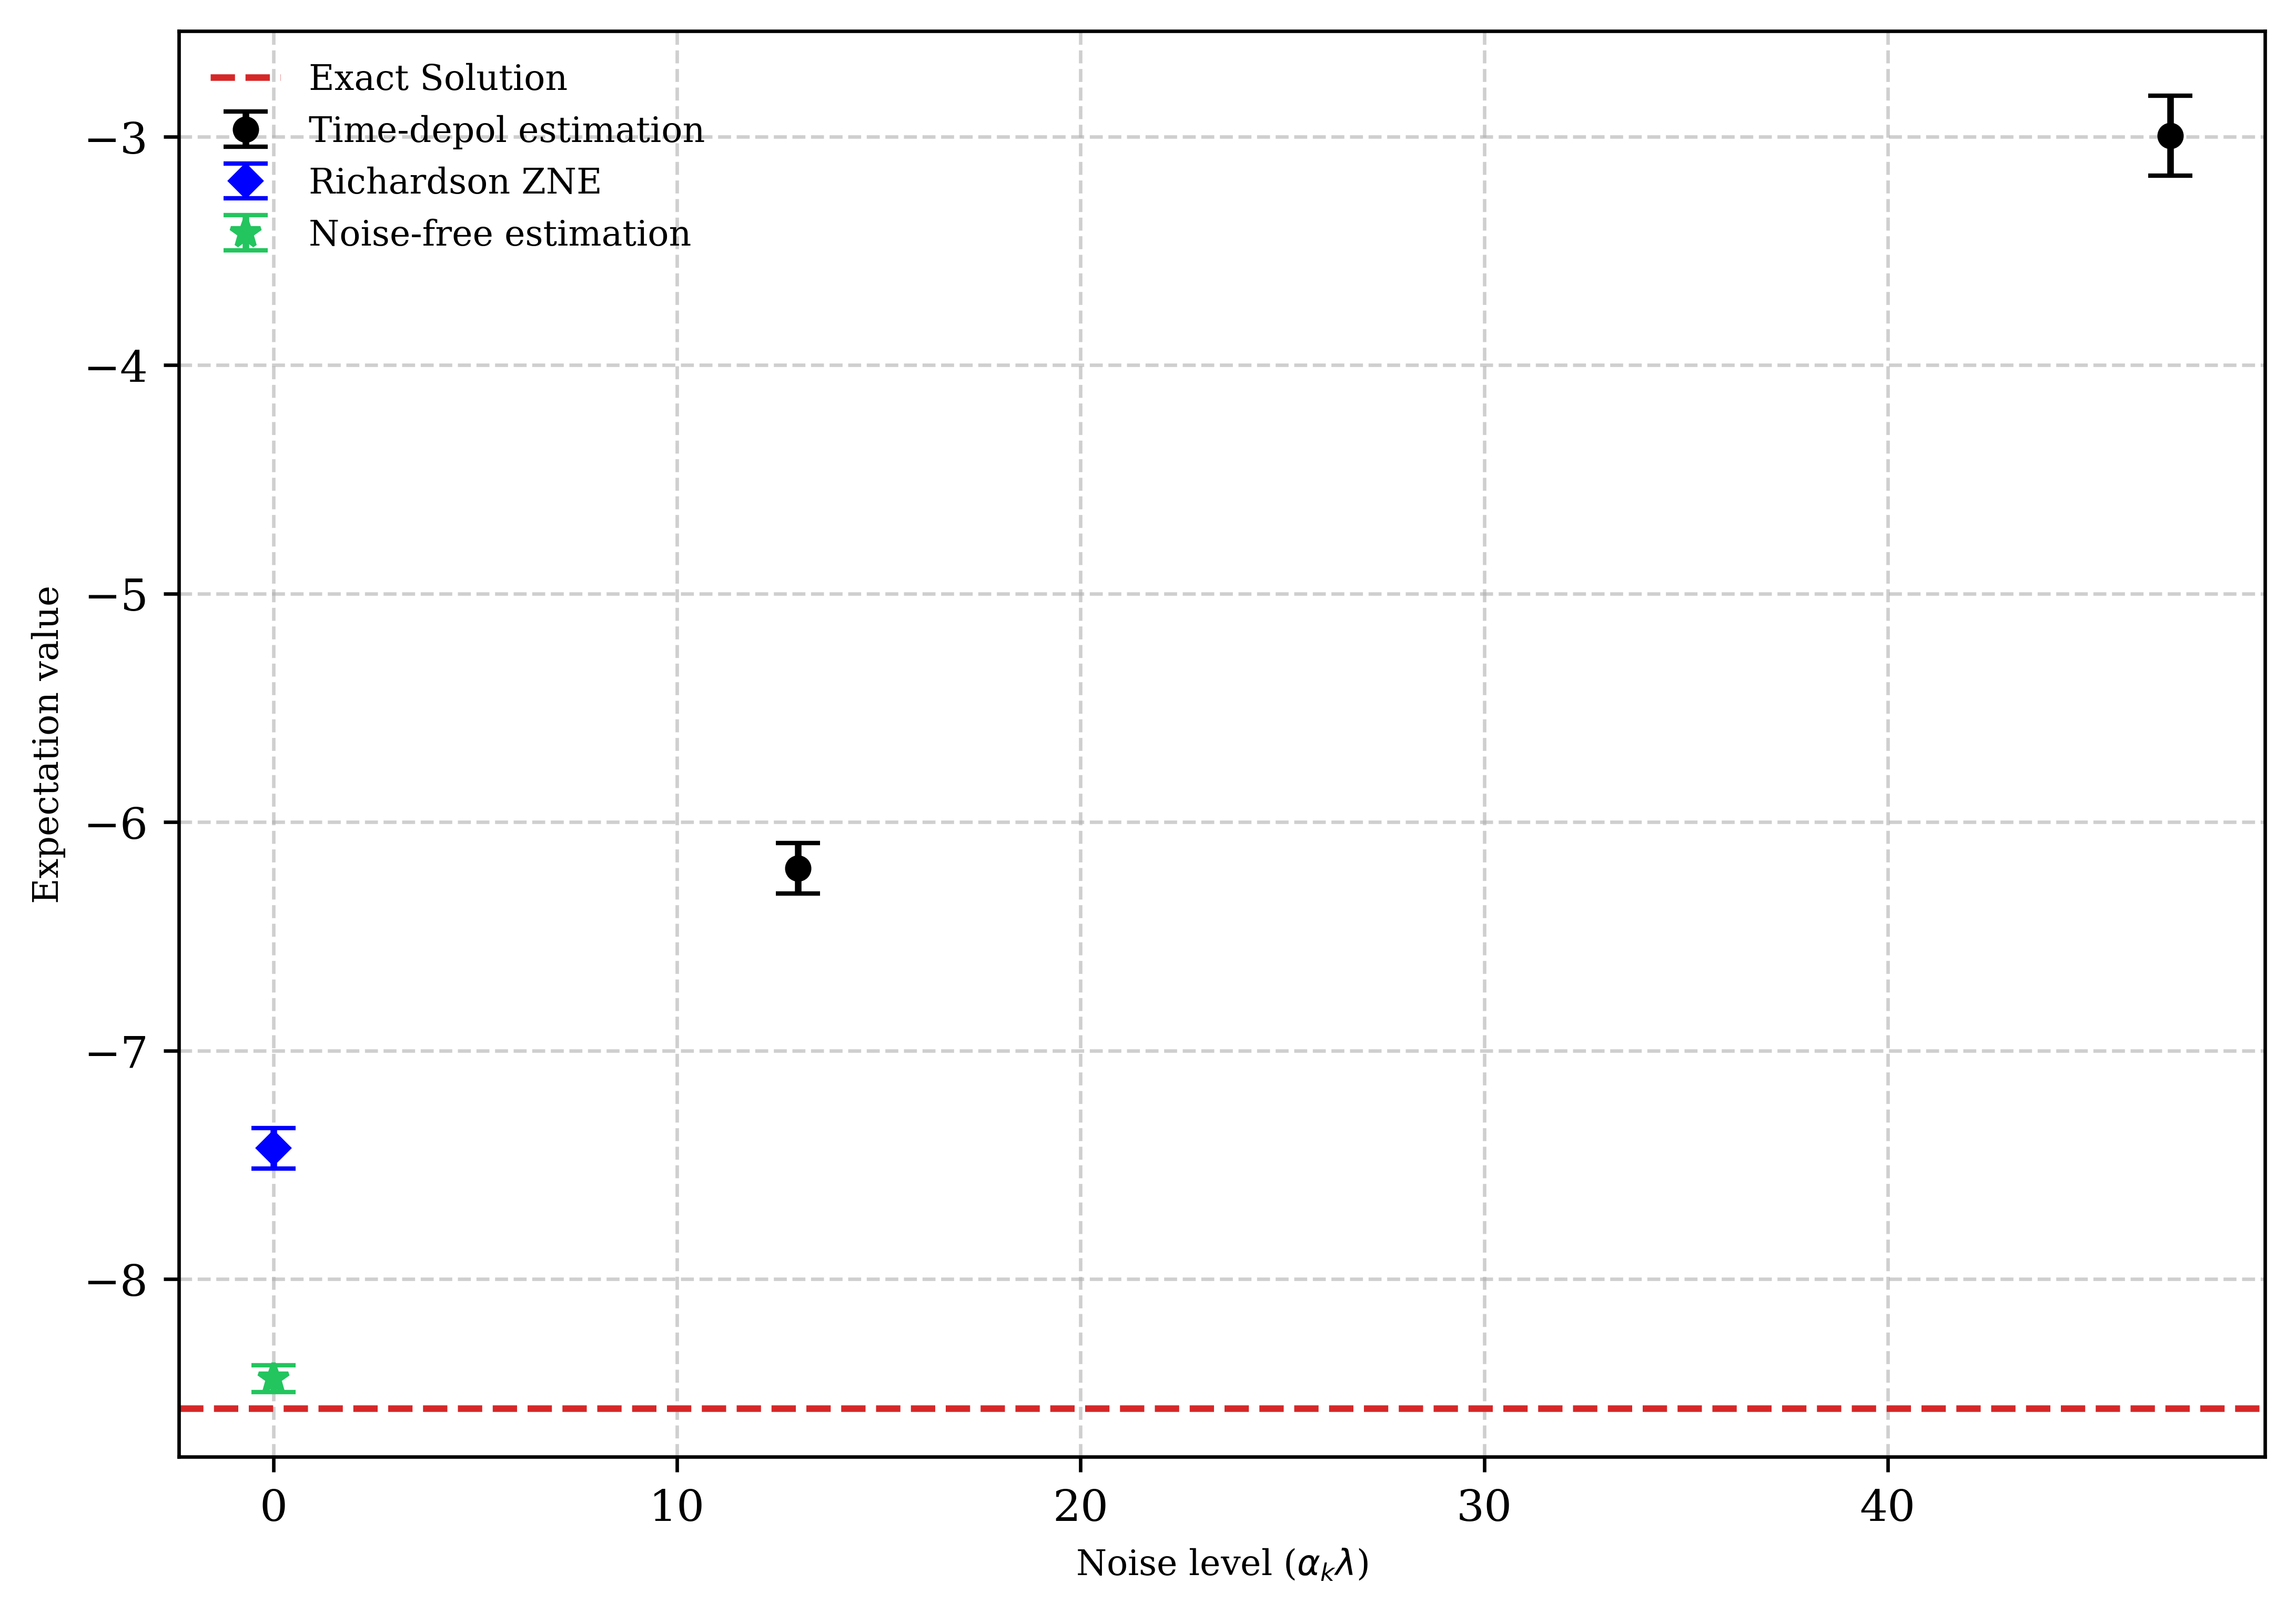

In [10]:
fig = plot_single_zne(
    data=PROCESSED_SIM_DATA["ZNE-single-var"]["ric2"],
    plot_colors=COLORS,
    title_fontsize = TITLE_FONT_SIZE,
    label_fontsize = LABEL_FONT_SIZE,
    #tick_fontsize = TICK_FONT_SIZE,
    legend_fontsize = LEGEND_FONT_SIZE,
    #plot_title="ZNE – Depolarizing noise",
    plot_file_name="zne_depol_noisy_evo_ric4",
    output_dir=OUTPUT_DIR,
    extrapol_target=0,
    save_format="eps",
    show_plot=True,
    print_data=True,
    figsize=(7.16, 5.0),   # 7.16 in wide — adjust height to taste
    dpi=600,
)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ Figure saved as (in 'reports' folder): zne_depol_noisy_evo_ric4.eps
{'noise_type': 'time-depol',
 'tmax': 20,
 'exact_sol': -8.566772233505624,
 'sorted_noise': [13, 183],
 'mean_exp_vals': [-6.201563991993811, -0.39880179414118344],
 'std_exp_vals': [0.11133119201572987, 0.06535776473471064],
 'zne_mean': -6.645304630653131,
 'zne_std': 0.11518407379243932,
 'mean_noise_off': -8.435520319786601,
 'std_noise_off': 0.05890072756156368,
 'degree': 3,
 'beta_mean': None,
 'beta_std': None,
 'cost_mean': 1.1646366782006918,
 'cost_std': 0.0}


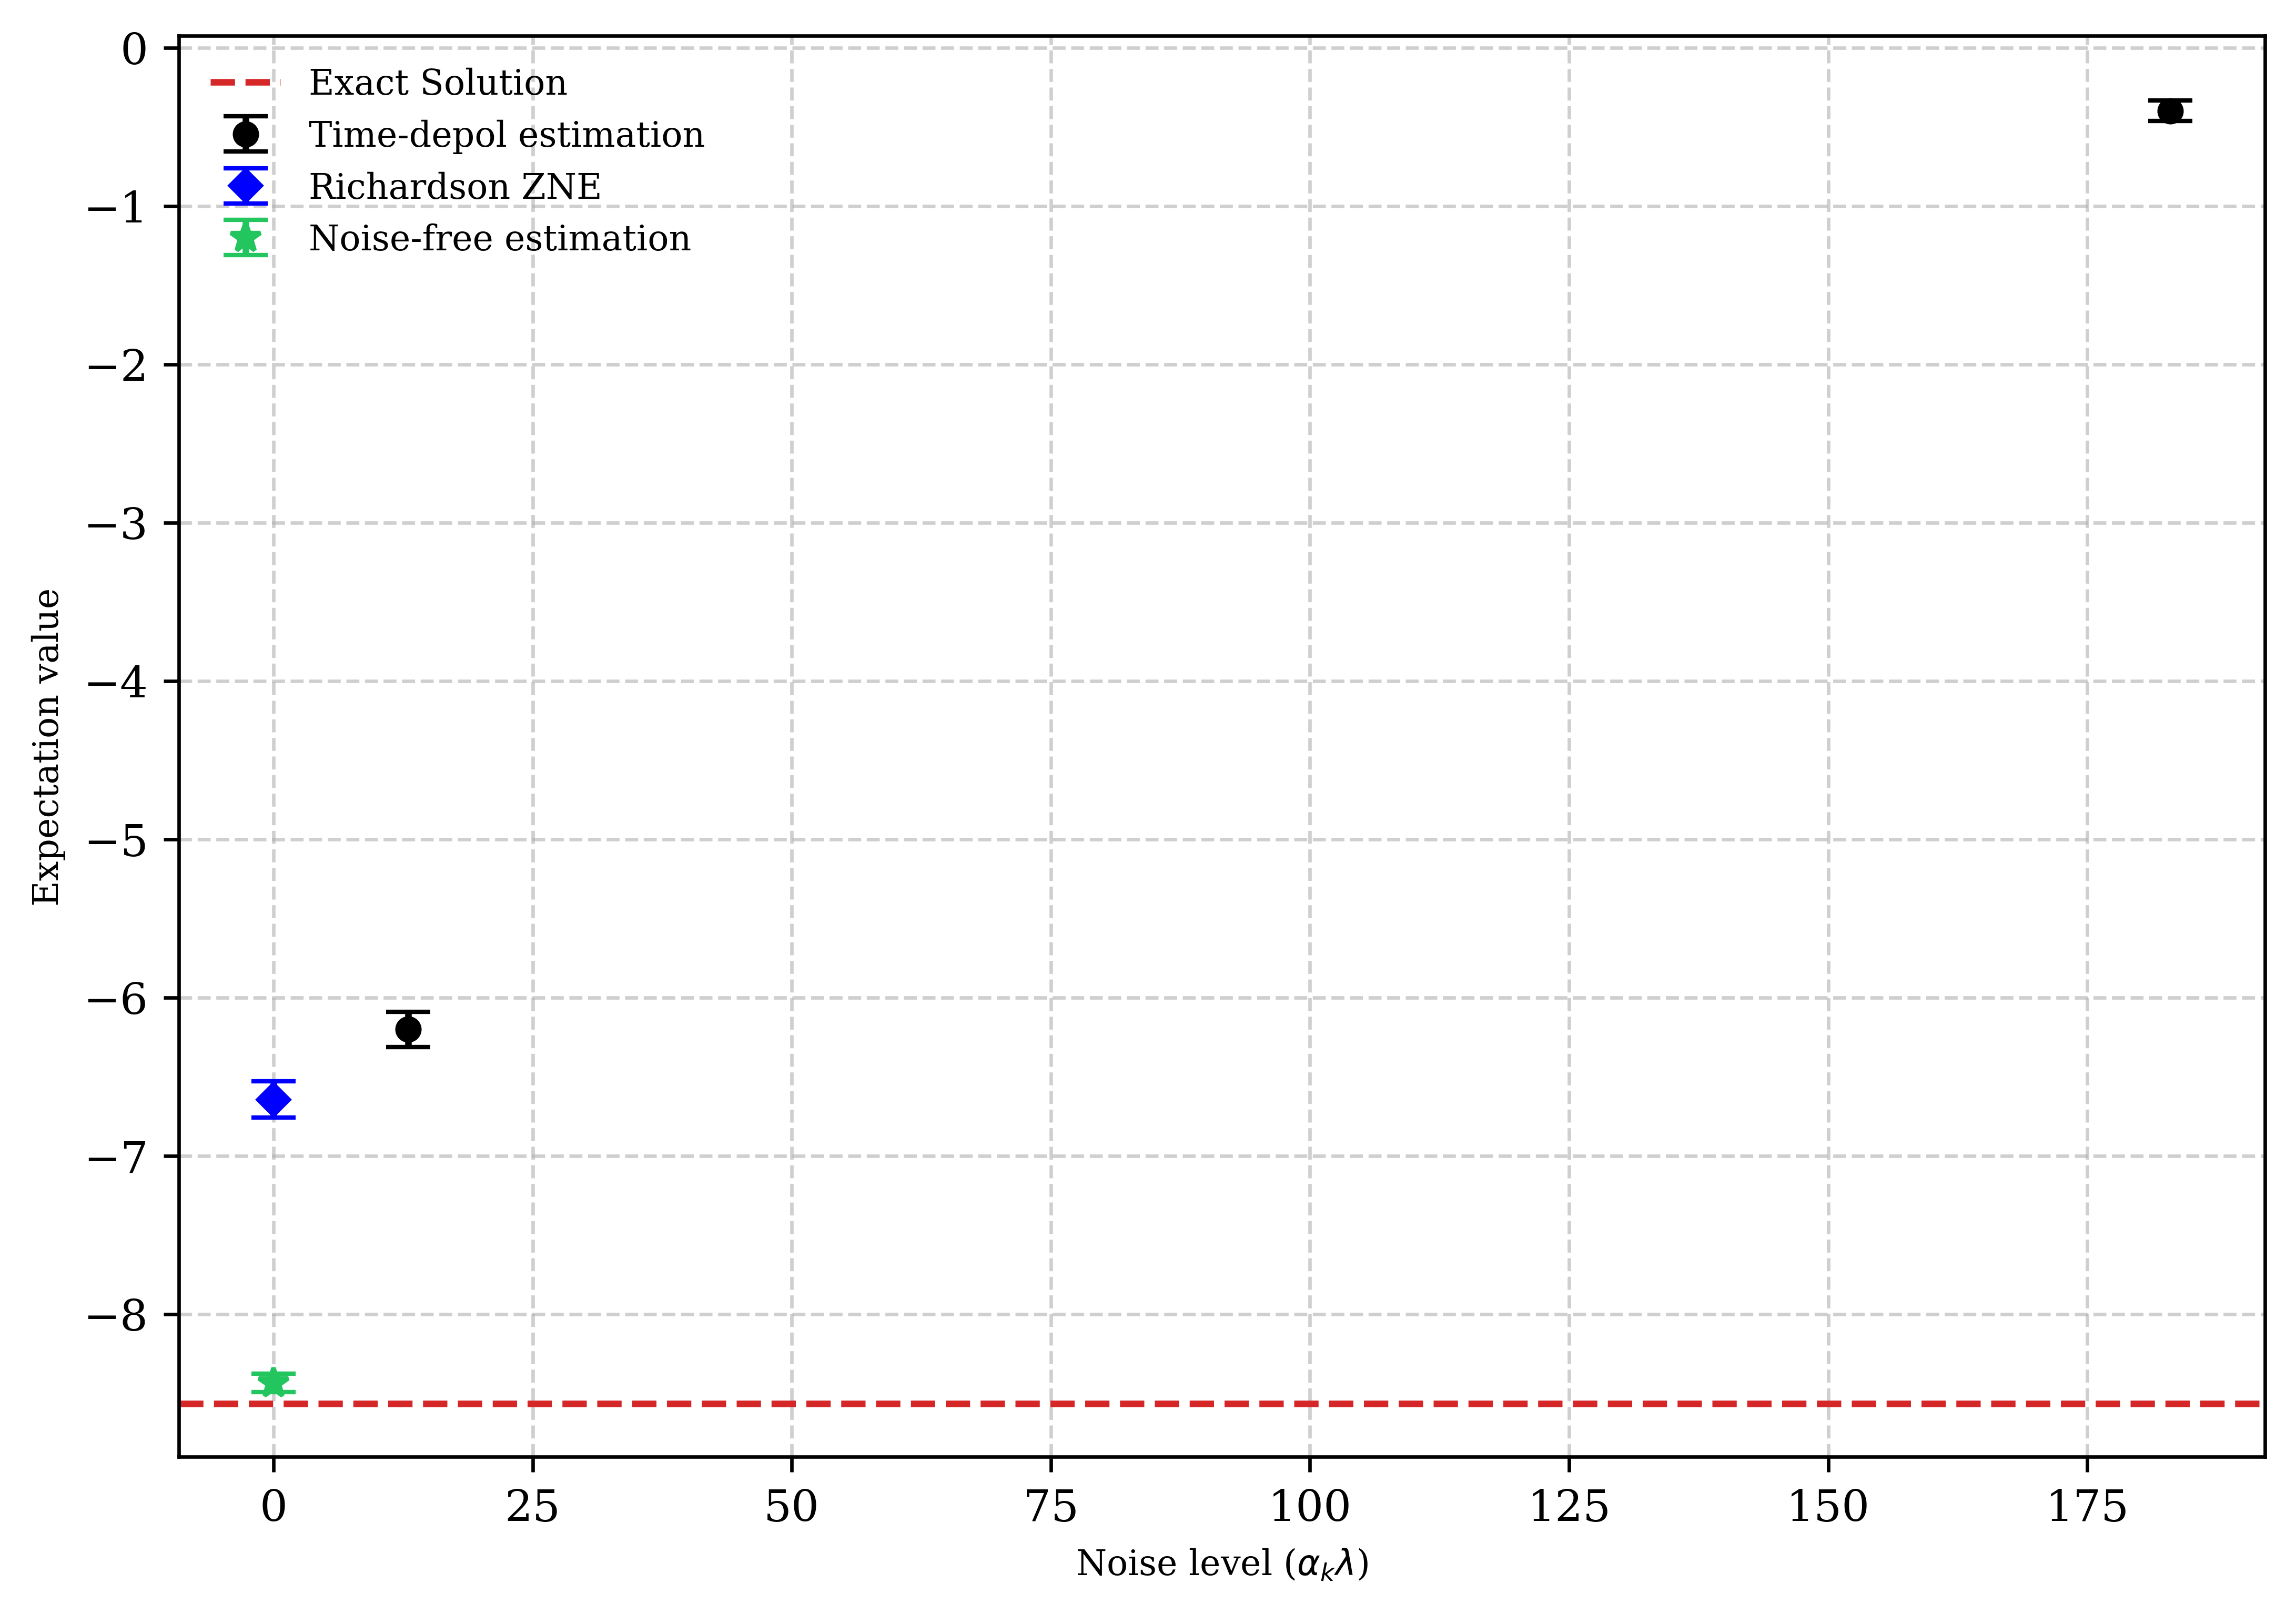

In [11]:
fig = plot_single_zne(
    data=PROCESSED_SIM_DATA["ZNE-single-var-learned-folding"]["ric2"],
    plot_colors=COLORS,
    title_fontsize = TITLE_FONT_SIZE,
    label_fontsize = LABEL_FONT_SIZE,
    #tick_fontsize = TICK_FONT_SIZE,
    legend_fontsize = LEGEND_FONT_SIZE,
    #plot_title="ZNE – Depolarizing noise",
    plot_file_name="zne_depol_noisy_evo_ric4",
    output_dir=OUTPUT_DIR,
    extrapol_target=0,
    save_format="eps",
    show_plot=True,
    print_data=True,
    figsize=(7.16, 5.0),   # 7.16 in wide — adjust height to taste
    dpi=600,
)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ Figure saved as (in 'reports' folder): xy-depol-diff-orders.eps


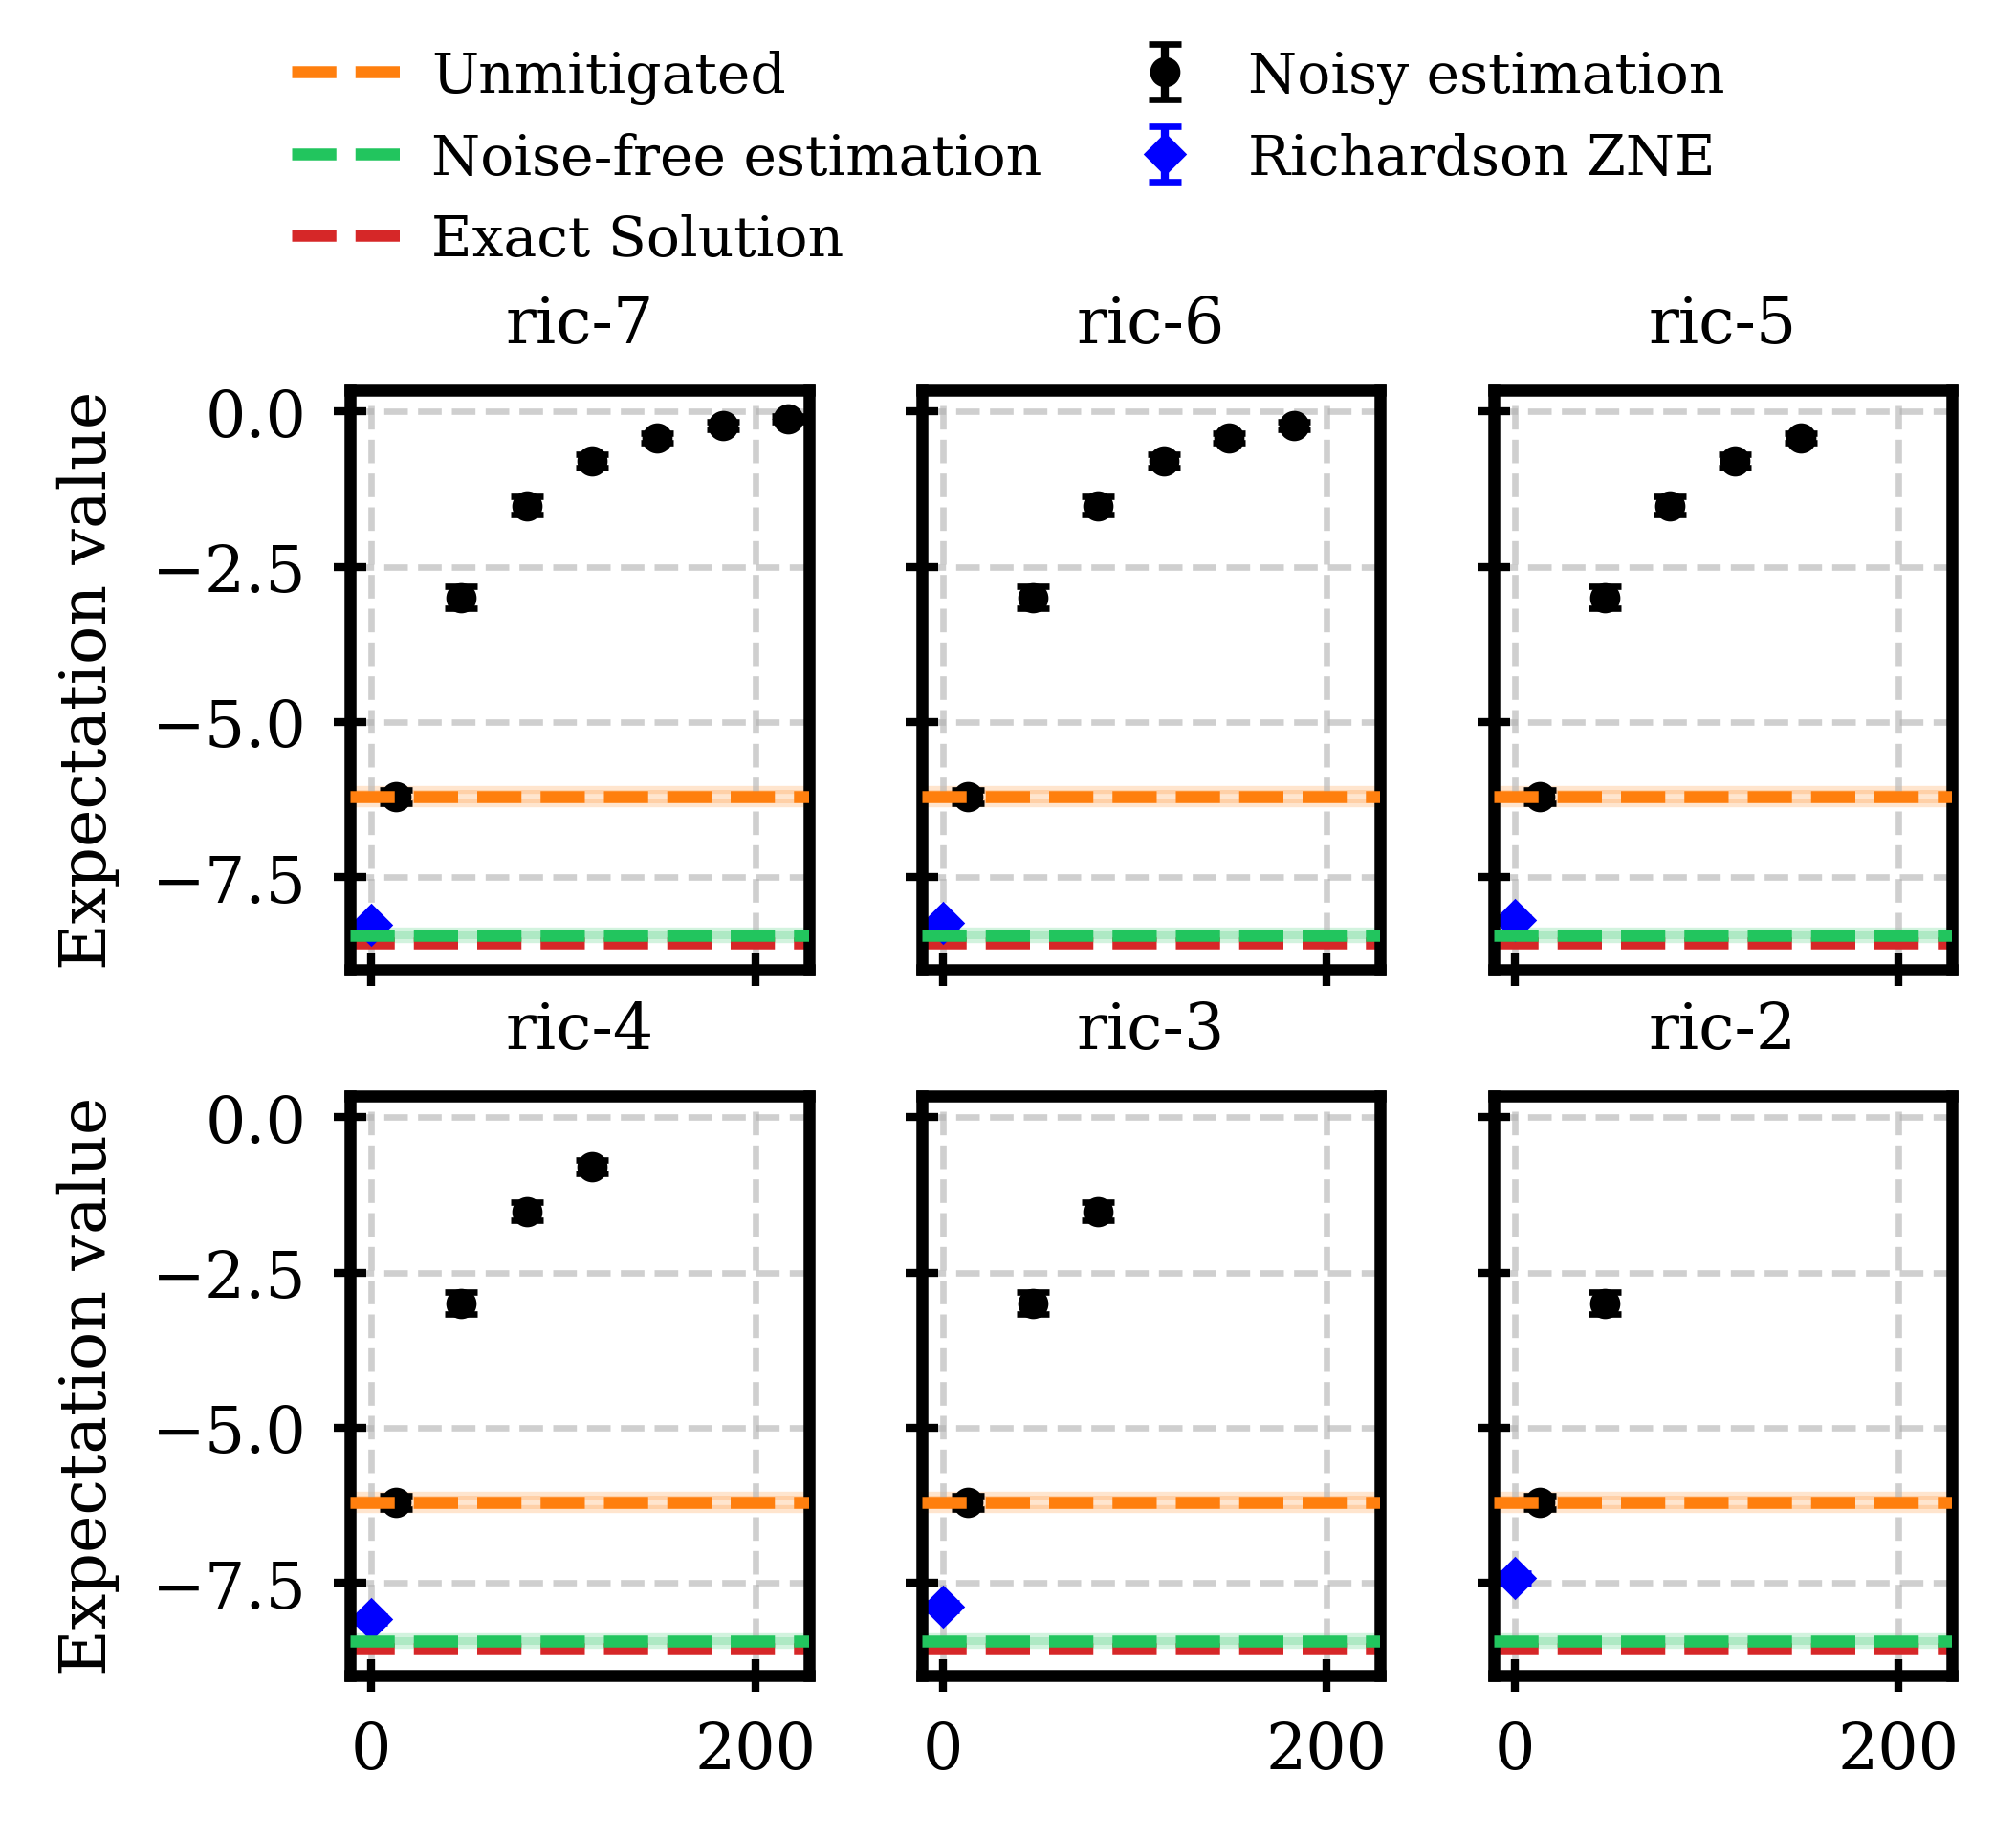

In [12]:
# pick which subcategories to include and in which order
subkeys = ["ric7", "ric6", "ric5", "ric4", "ric3", "ric2"]  # or specify a subset like ["ric2", "ric3", "ric4", "ric5", "ric6"]

data_list   = [PROCESSED_SIM_DATA["ZNE-single-var"][k] for k in subkeys]
plot_titles = subkeys   # or any custom labels you want per panel

fig = plot_multi_zne(
    data_list             = data_list,
    #plot_titles           = subkeys,
    sharex                = True,
    plot_colors           = COLORS,
    xlabel = None,
    ylabel = "Expectation value",
    title_fontsize        = TITLE_FONT_SIZE,
    label_fontsize        = LABEL_FONT_SIZE,
    tick_fontsize         = TICK_FONT_SIZE,
    legend_fontsize       = LEGEND_FONT_SIZE-1,
    marker_size           = 3,
    capsize               = 2,
    plot_file_name        = "xy-depol-diff-orders",
    output_dir            = OUTPUT_DIR,
    plot_titles           = ["ric-7", "ric-6", "ric-5", "ric-4", "ric-3", "ric-2"],
    #panel_label_y         = -0.20,
    ncols                 = 3,
    figsize               = (3.45, 3.5),
    dpi                   = 600,
    sharey                = True,
    show_legend           = True,
    global_legend         = True,
    legend_loc            = "upper center",
    #legend_bbox           = (0.5, 0.95),
    legend_ncols          = 2,
    subplot_top           = 0.82,
    subplot_bottom        = 0.18,
    save_format           = "eps",
    show_plot             = True,
)

Cost of single variate Richardon extrapolation

In [13]:
PROCESSED_SIM_DATA["ZNE-single-var"].keys()

dict_keys(['ric6', 'ric7', 'ric5', 'ric3', 'ric4', 'ric2'])

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


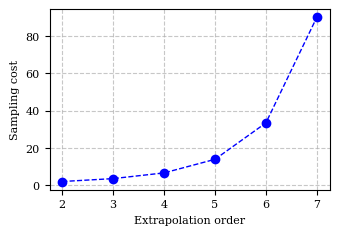

In [14]:
# Data extraction and sorting
x_vals = [len(v['sorted_noise']) for v in PROCESSED_SIM_DATA["ZNE-single-var"].values()]
y_vals = [v['cost_mean'] for v in PROCESSED_SIM_DATA["ZNE-single-var"].values()]
sorted_data = sorted(zip(x_vals, y_vals))
x_sorted, y_sorted = zip(*sorted_data)

# Exact figure size
fig_width = 3.5  # inches (strict)
fig_height = 3.5 * (1571 / 2070)  # preserve aspect ratio

# Create plot
plt.figure(figsize=(fig_width, fig_height))
plt.plot(x_sorted, y_sorted, marker='o', linestyle='--', color='#0000ff', linewidth=1)

plt.xlabel('Extrapolation order', fontsize=8)
plt.ylabel('Sampling cost', fontsize=8)
#plt.title('Overhead', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
# Adjust margins to prevent label/title cropping
plt.subplots_adjust(left=0.18, right=0.98, top=0.88, bottom=0.20)
# Save (strict DPI)
plt.savefig(os.path.join(OUTPUT_DIR, "overhead.eps"), format="eps", dpi=600)
plt.show()
plt.close()

---
## Table

In [15]:

# ── Helper: convert PROCESSED_SIM_DATA → ordered list ────────────────────────
def build_data_list(processed_sim_data: dict) -> list:
    """
    Converts PROCESSED_SIM_DATA["ZNE-single-var"] into the flat list expected
    by make_zne_table(), ordered from most noise levels (ric7) to fewest (ric2).
    """
    zne_data = processed_sim_data["ZNE-single-var"]
    keys_sorted = sorted(
        zne_data.keys(),
        key=lambda k: len(zne_data[k]["sorted_noise"]),
        reverse=True,
    )
    return [zne_data[k] for k in keys_sorted]


# ── Core table function ───────────────────────────────────────────────────────
def make_zne_table(
    data_list: list,
    fig_width: float,          # final rendered width in inches — required
    dpi: int,                  # output DPI — required
    output_dir: str = "reports",
    filename_stem: str = "zne_table",
    row_height: float = 0.28,  # inches per row; tune to control table height
    fontsize: float = 8,
    save_eps: bool = True,
    save_png: bool = True,
) -> plt.Figure:
    """
    Parameters
    ----------
    data_list : list of dicts
        Each dict must contain:
            sorted_noise   – list of noise levels used
            mean_exp_vals  – list of mean expectation values per noise level
            std_exp_vals   – list of std dev per noise level
            zne_mean       – ZNE extrapolated mean
            zne_std        – ZNE extrapolated std
            mean_noise_off – noise-free estimation mean
            std_noise_off  – noise-free estimation std
        Ordered from most noise levels (ric7) to fewest (ric2).
    fig_width : float
        Final rendered figure width in inches (strictly honoured).
    dpi : int
        Output DPI (strictly honoured). Also sets rcParams for display.
    output_dir : str
        Directory to write output files.
    filename_stem : str
        Base filename without extension.
    row_height : float
        Height of each table row in inches.
    fontsize : float
        Font size for all table text (points).
    save_eps : bool
    save_png : bool

    Returns
    -------
    matplotlib Figure
    """

    # ── Reference entry: most noise levels (first in list) ───────────────────
    ref = data_list[0]

    # ── Build row labels and value strings ────────────────────────────────────
    row_labels = []
    row_values = []

    # Section 1 – Noise-free
    row_labels.append("Noise-free estimation")
    row_values.append(
        f"{ref['mean_noise_off']:.3f} \u00b1 {ref['std_noise_off']:.3f}"
    )

    # Section 2 – Individual noise levels
    for idx, (noise_val, mean_val, std_val) in enumerate(
        zip(ref["sorted_noise"], ref["mean_exp_vals"], ref["std_exp_vals"])
    ):
        label = ("Base noise=" + str(noise_val)) if idx == 0 else ("Boosted noise=" + str(noise_val))
        row_labels.append(label)
        row_values.append(f"{mean_val:.3f} \u00b1 {std_val:.3f}")

    # Section 3 – ZNE values, 2-point → N-point
    for entry in reversed(data_list):
        n_pts = len(entry["sorted_noise"])
        row_labels.append(f"{n_pts}-point Richardson (ric-{n_pts}) ZNE value")
        row_values.append(f"{entry['zne_mean']:.3f} \u00b1 {entry['zne_std']:.3f}")

    # ── Section divider positions ─────────────────────────────────────────────
    n_noise_rows   = len(ref["sorted_noise"])
    section_breaks = [1, 1 + n_noise_rows]

    # ── Figure ────────────────────────────────────────────────────────────────
    n_rows = len(row_labels)
    fig_h  = n_rows * row_height

    matplotlib.rcParams["figure.dpi"] = dpi

    fig, ax = plt.subplots(figsize=(fig_width, fig_h))
    ax.set_axis_off()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, n_rows)

    # Remove all automatic padding — preserves exact figsize on save.
    # Do NOT use bbox_inches="tight" in savefig; it resizes the canvas.
    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)

    PAD_L = 0.012
    PAD_R = 0.012

    # ── Draw rows ─────────────────────────────────────────────────────────────
    for i, (label, value) in enumerate(zip(row_labels, row_values)):
        y_center = n_rows - i - 0.5
        bold     = (i == 0)

        ax.text(
            PAD_L, y_center, label,
            va="center", ha="left",
            fontsize=fontsize,
            fontweight="bold" if bold else "normal",
            transform=ax.transData,
        )
        ax.text(
            1 - PAD_R, y_center, value,
            va="center", ha="right",
            fontsize=fontsize,
            fontweight="bold" if bold else "normal",
            transform=ax.transData,
        )

    # ── Horizontal rules ──────────────────────────────────────────────────────
    ax.axhline(n_rows, color="black", lw=1.0)
    ax.axhline(0,      color="black", lw=1.0)
    for sb in section_breaks:
        ax.axhline(n_rows - sb, color="black", lw=0.6)

    # ── Save ──────────────────────────────────────────────────────────────────
    os.makedirs(output_dir, exist_ok=True)

    if save_eps:
        eps_path = os.path.join(output_dir, f"{filename_stem}.eps")
        fig.savefig(eps_path, format="eps", dpi=dpi)
        print(f"Saved EPS → {eps_path}  |  width={fig.get_figwidth():.4f} in  dpi={dpi}")

    if save_png:
        png_path = os.path.join(output_dir, f"{filename_stem}.png")
        fig.savefig(png_path, format="png", dpi=dpi)
        from PIL import Image
        img = Image.open(png_path)
        print(
            f"Saved PNG → {png_path}  |  "
            f"{img.size[0]}x{img.size[1]} px  "
            f"({img.size[0]/dpi:.4f} x {img.size[1]/dpi:.4f} in at {dpi} dpi)"
        )
    plt.close(fig)
    # ── Generate LaTeX String ────────────────────────────────────────────────
    latex_lines = ["\\hline"]

    # Section 1: Noise-free
    latex_lines.append(
        f"        Noise-free estimation & ${ref['mean_noise_off']:.3f} \\pm {ref['std_noise_off']:.3f} $\\\\"
    )
    latex_lines.append("        \\hline")

    # Section 2: Individual noise levels
    for idx, (noise_val, mean_val, std_val) in enumerate(
        zip(ref["sorted_noise"], ref["mean_exp_vals"], ref["std_exp_vals"])
    ):
        label = "At base noise" if idx == 0 else "At boosted noise"
        latex_lines.append(
            f"        {label} $= {noise_val}$ & ${mean_val:.3f} \\pm {std_val:.3f} $\\\\"
        )
    latex_lines.append("        \\hline")

    # Section 3: ZNE Values (No bold)
    for entry in reversed(data_list):
        n_pts = len(entry["sorted_noise"])
        label = f"\\text{{{n_pts}-point Richardson (RIC-{n_pts}) ZNE value}}"
        val_str = f"{entry['zne_mean']:.3f} \\pm {entry['zne_std']:.3f}"
        latex_lines.append(f"        {label} & ${val_str}$ \\\\")
    latex_lines.append("        \\hline")

    # Join and print
    latex_output = "\n".join(latex_lines)
    print("\n--- LaTeX Table Code ---")
    print(latex_output)
    print("------------------------\n")

    # Optional: Save to .tex file
    with open(os.path.join(output_dir, f"{filename_stem}.tex"), "w") as f:
        f.write(latex_output)

    return fig

Saved EPS → reports/zne-table-1.eps  |  width=3.5000 in  dpi=600
Saved PNG → reports/zne-table-1.png  |  2100x1512 px  (3.5000 x 2.5200 in at 600 dpi)

--- LaTeX Table Code ---
\hline
        Noise-free estimation & $-8.436 \pm 0.059 $\\
        \hline
        At base noise $= 13$ & $-6.202 \pm 0.111 $\\
        At boosted noise $= 47$ & $-2.995 \pm 0.174 $\\
        At boosted noise $= 81$ & $-1.515 \pm 0.146 $\\
        At boosted noise $= 115$ & $-0.793 \pm 0.107 $\\
        At boosted noise $= 149$ & $-0.423 \pm 0.077 $\\
        At boosted noise $= 183$ & $-0.227 \pm 0.055 $\\
        At boosted noise $= 217$ & $-0.120 \pm 0.040 $\\
        \hline
        \text{2-point Richardson (RIC-2) ZNE value} & $-7.427 \pm 0.089$ \\
        \text{3-point Richardson (RIC-3) ZNE value} & $-7.884 \pm 0.066$ \\
        \text{4-point Richardson (RIC-4) ZNE value} & $-8.087 \pm 0.051$ \\
        \text{5-point Richardson (RIC-5) ZNE value} & $-8.187 \pm 0.043$ \\
        \text{6-point Richardson (R

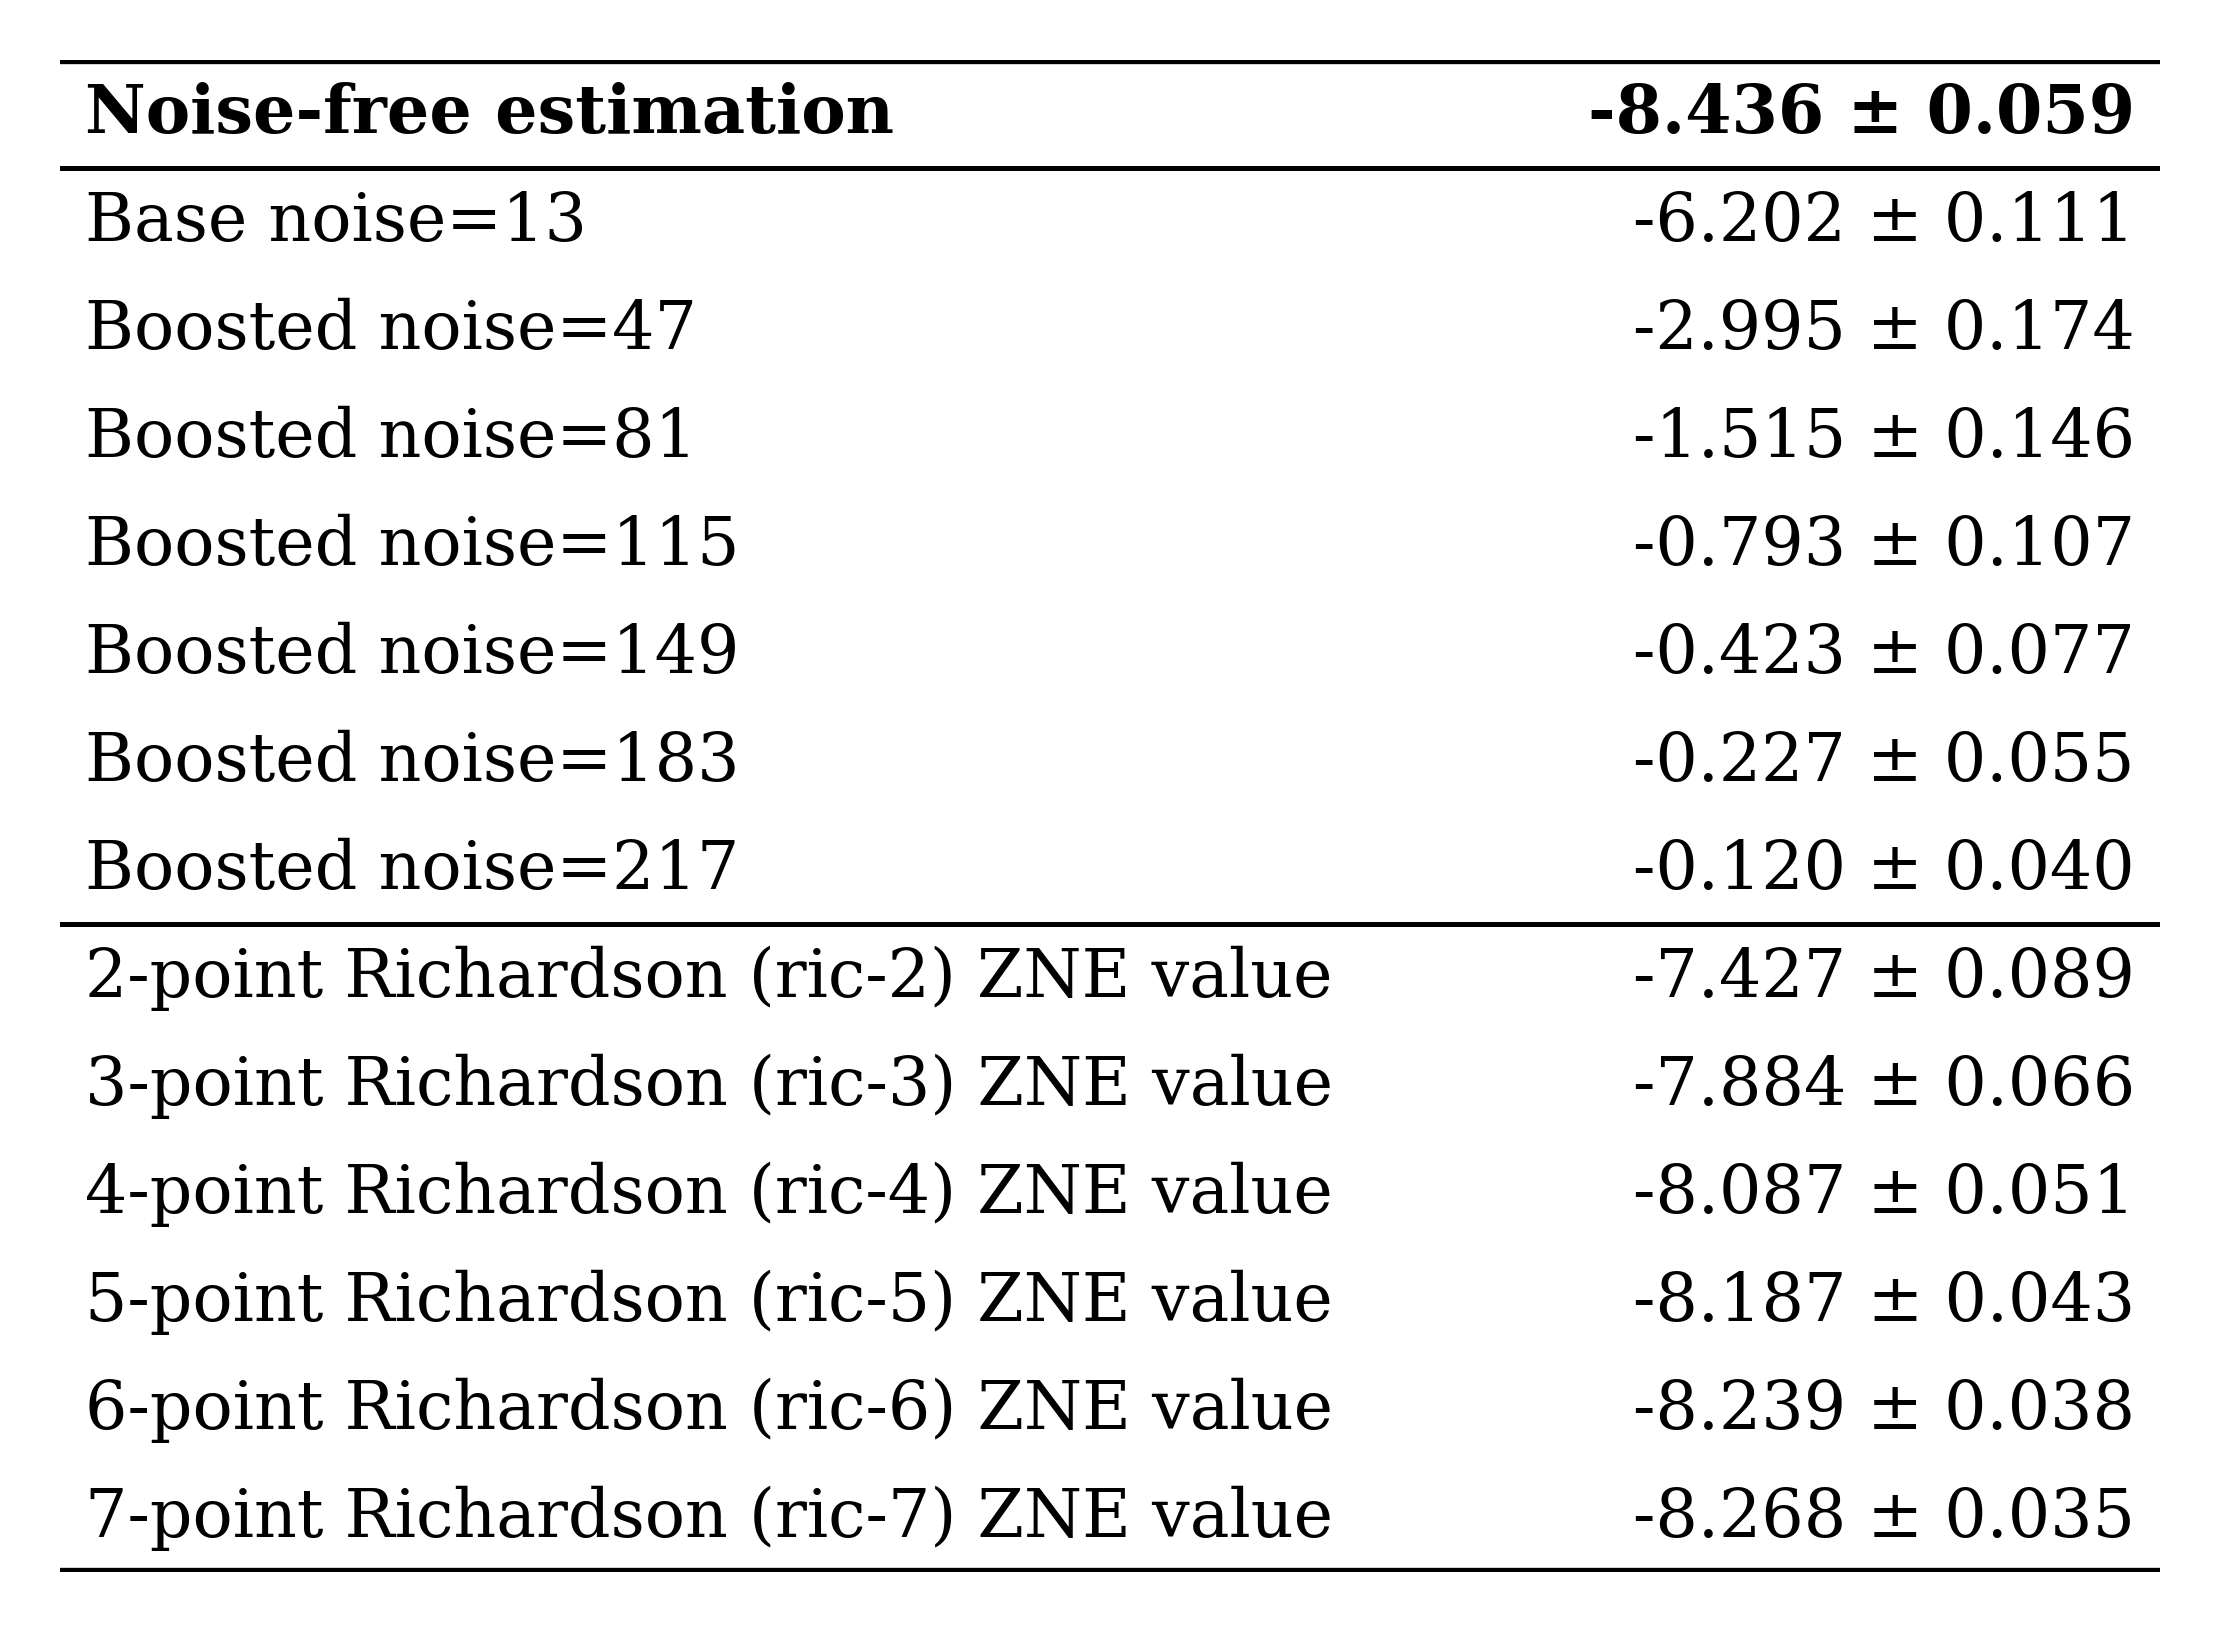

In [16]:
make_zne_table(data_list, output_dir=OUTPUT_DIR, filename_stem="zne-table-1", fontsize = 8, row_height = 0.18, fig_width=3.5, dpi=600)

---

## Multivariate Richardson Extrapolation

We use identity factors, specifically the number of foldings `[IR, ICZ, IU, IY]`, to generate folded redundant circuits which exhibit higher noise levels.

In [17]:
# n-nariables, order of extrapolation, and noise boost step size
l, d, Delta = 4, 1, 1
ms = [m for m in iproduct(range(d+1), repeat=l) if sum(m) <= d]

lambdas = [[1 + Delta*mi for mi in m] for m in ms]
# [(1,1,1),(1,1,2),(1,1,3),(1,2,1),(1,2,2),(1,3,1),(2,1,1),(2,1,2),(2,2,1),(3,1,1)]
# cond(A) ≈ 30  ← much better
print("Linearly independent identity factors:")
print("Length: ", len(lambdas))
print(lambdas)

Linearly independent identity factors:
Length:  5
[[1, 1, 1, 1], [1, 1, 1, 2], [1, 1, 2, 1], [1, 2, 1, 1], [2, 1, 1, 1]]


We count the number of gates as `[nR, nCZ, nT, nY]` for a given `[IR, ICZ, IU, IY]`.

To transition from the identity factors space to the noise level (gate number) space, we applied a transformation to the noise parameters:

$$(nR, nCZ, nT, nY) \to (nR + nY, nCZ, nT)$$

Consequently, the number of variables is reduced to 3.

In [18]:
# We applied a transformation to noise prameters
# (nR, nCZ, nT, nY)---> (nR+nY, nCZ, nT)
# so the number of variables is reduced to 3
require_point_gate_count_space = math.factorial((l-1) + d) // (math.factorial(l-1) * math.factorial(d))  # combinatorial count of valid m-tuples
print("Require points for IFACTORs: ", require_point_gate_count_space)

Require points for IFACTORs:  4


In [19]:
[[0, 0, 0, 0], *lambdas[:len(lambdas)-1]][:require_point_gate_count_space]

[[0, 0, 0, 0], [1, 1, 1, 1], [1, 1, 1, 2], [1, 1, 2, 1]]

In [20]:
PROCESSED_SIM_DATA["ZNE-mul-var"]["muld1"]

{'noise_type': 'time-depol',
 'tmax': 20,
 'exact_sol': -8.566772233505624,
 'sorted_noise': [[4, 2, 7],
  [36, 6, 21],
  [36, 10, 21],
  [52, 6, 21],
  [60, 6, 35]],
 'mean_exp_vals': [-6.201563991993813,
  -2.262250067987972,
  -1.7323117384192042,
  -1.721259165442452,
  -1.2788227135206962],
 'std_exp_vals': [0.11133119201572964,
  0.16650614572711395,
  0.15875469944239698,
  0.15278062905532963,
  0.1304195253338665],
 'zne_mean': -7.765477777087601,
 'zne_std': 0.07638971338262529,
 'mean_noise_off': -8.435520319786601,
 'std_noise_off': 0.05890072756156368,
 'degree': 1,
 'beta_mean': [1.5000000000000018,
  -1.2500000000000013,
  0.7500000000000008,
  0.0],
 'beta_std': [0.0, 2.220446049250313e-16, 0.0, 0.0],
 'cost_mean': 12.250000000000025,
 'cost_std': 0.0}

/home/arijit/Desktop/My Folder/indirect-zne/src/nbutils/master.py:1247: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


💾 Saved: reports/muld1_tmax20.png
💾 Saved: reports/muld1_tmax20.eps


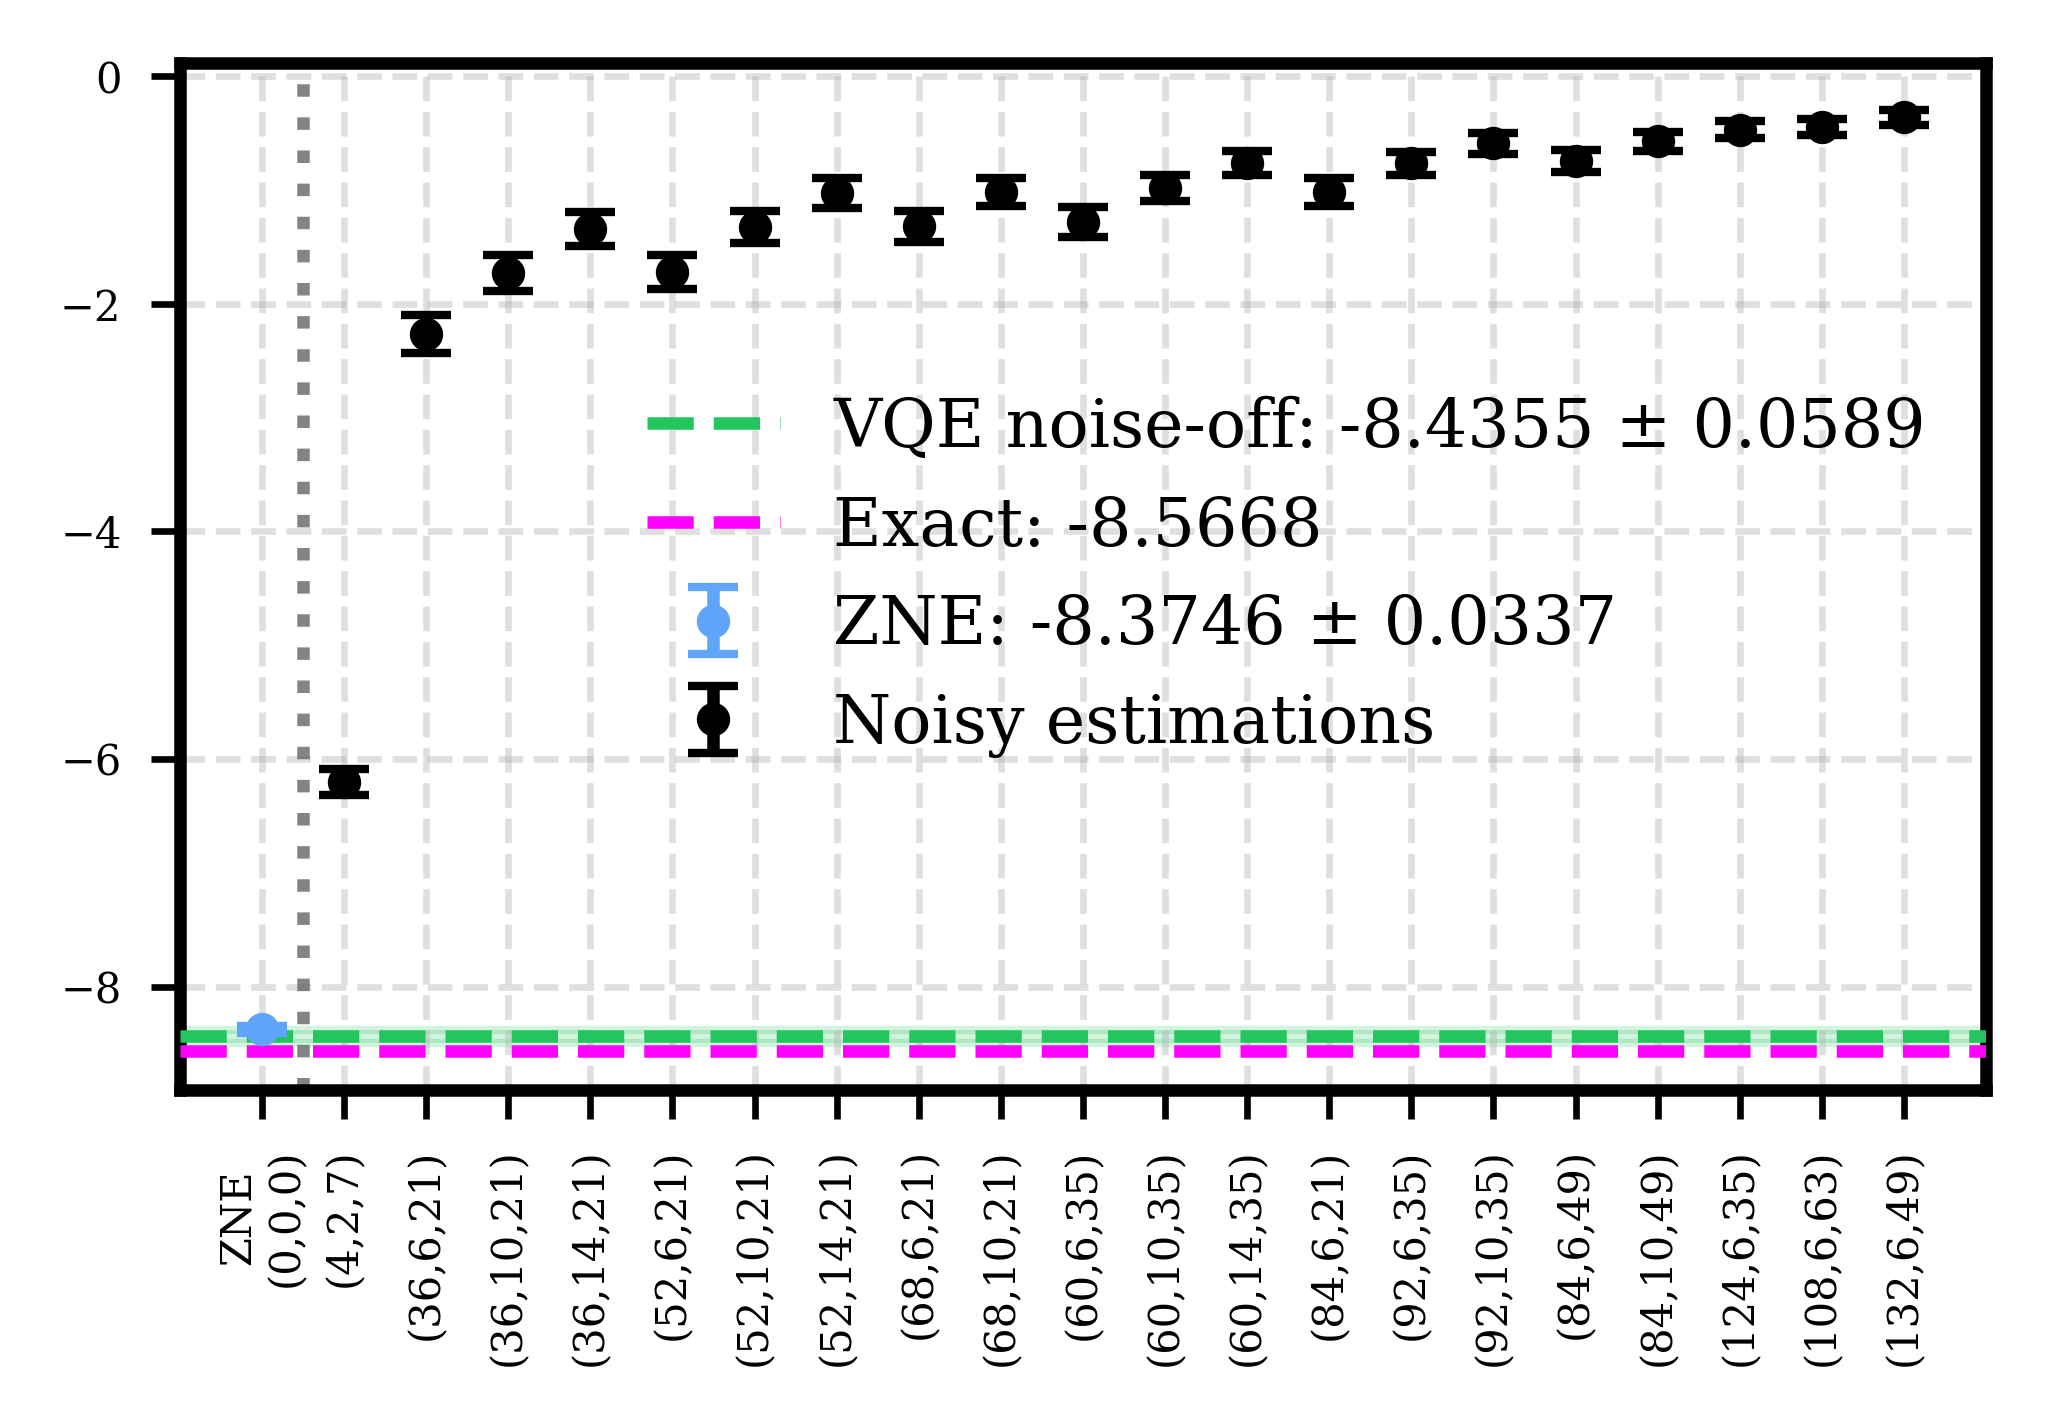

In [21]:
plot_zne_mul_var_single(
    data           = PROCESSED_SIM_DATA["ZNE-mul-var"]["muld3"],
    plot_colors    = {"zne": "#60a5fa", "noisy": "black",
                      "exact": "magenta", "noise_off": "#22c55e"},
    plot_file_name = "muld1_tmax20",
    output_dir     = OUTPUT_DIR,
    #plot_title     = "Multivariate ZNE",
    tick_fontsize  = 5,
    label_fontsize = 8,
    capsize  = 3,
    marker_size  = 3,
    border_width  = 1.5,
    legend_outside_plot = False,
    save_format    = ["png", "eps"],
    show_plot      = False,
    figsize               = FIG_SIZE_IEEE_DOUBLE,
    dpi                   = 600,
)

/home/arijit/Desktop/My Folder/indirect-zne/src/nbutils/master.py:1247: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


💾 Saved: reports/muld1_tmax20.png
💾 Saved: reports/muld1_tmax20.eps


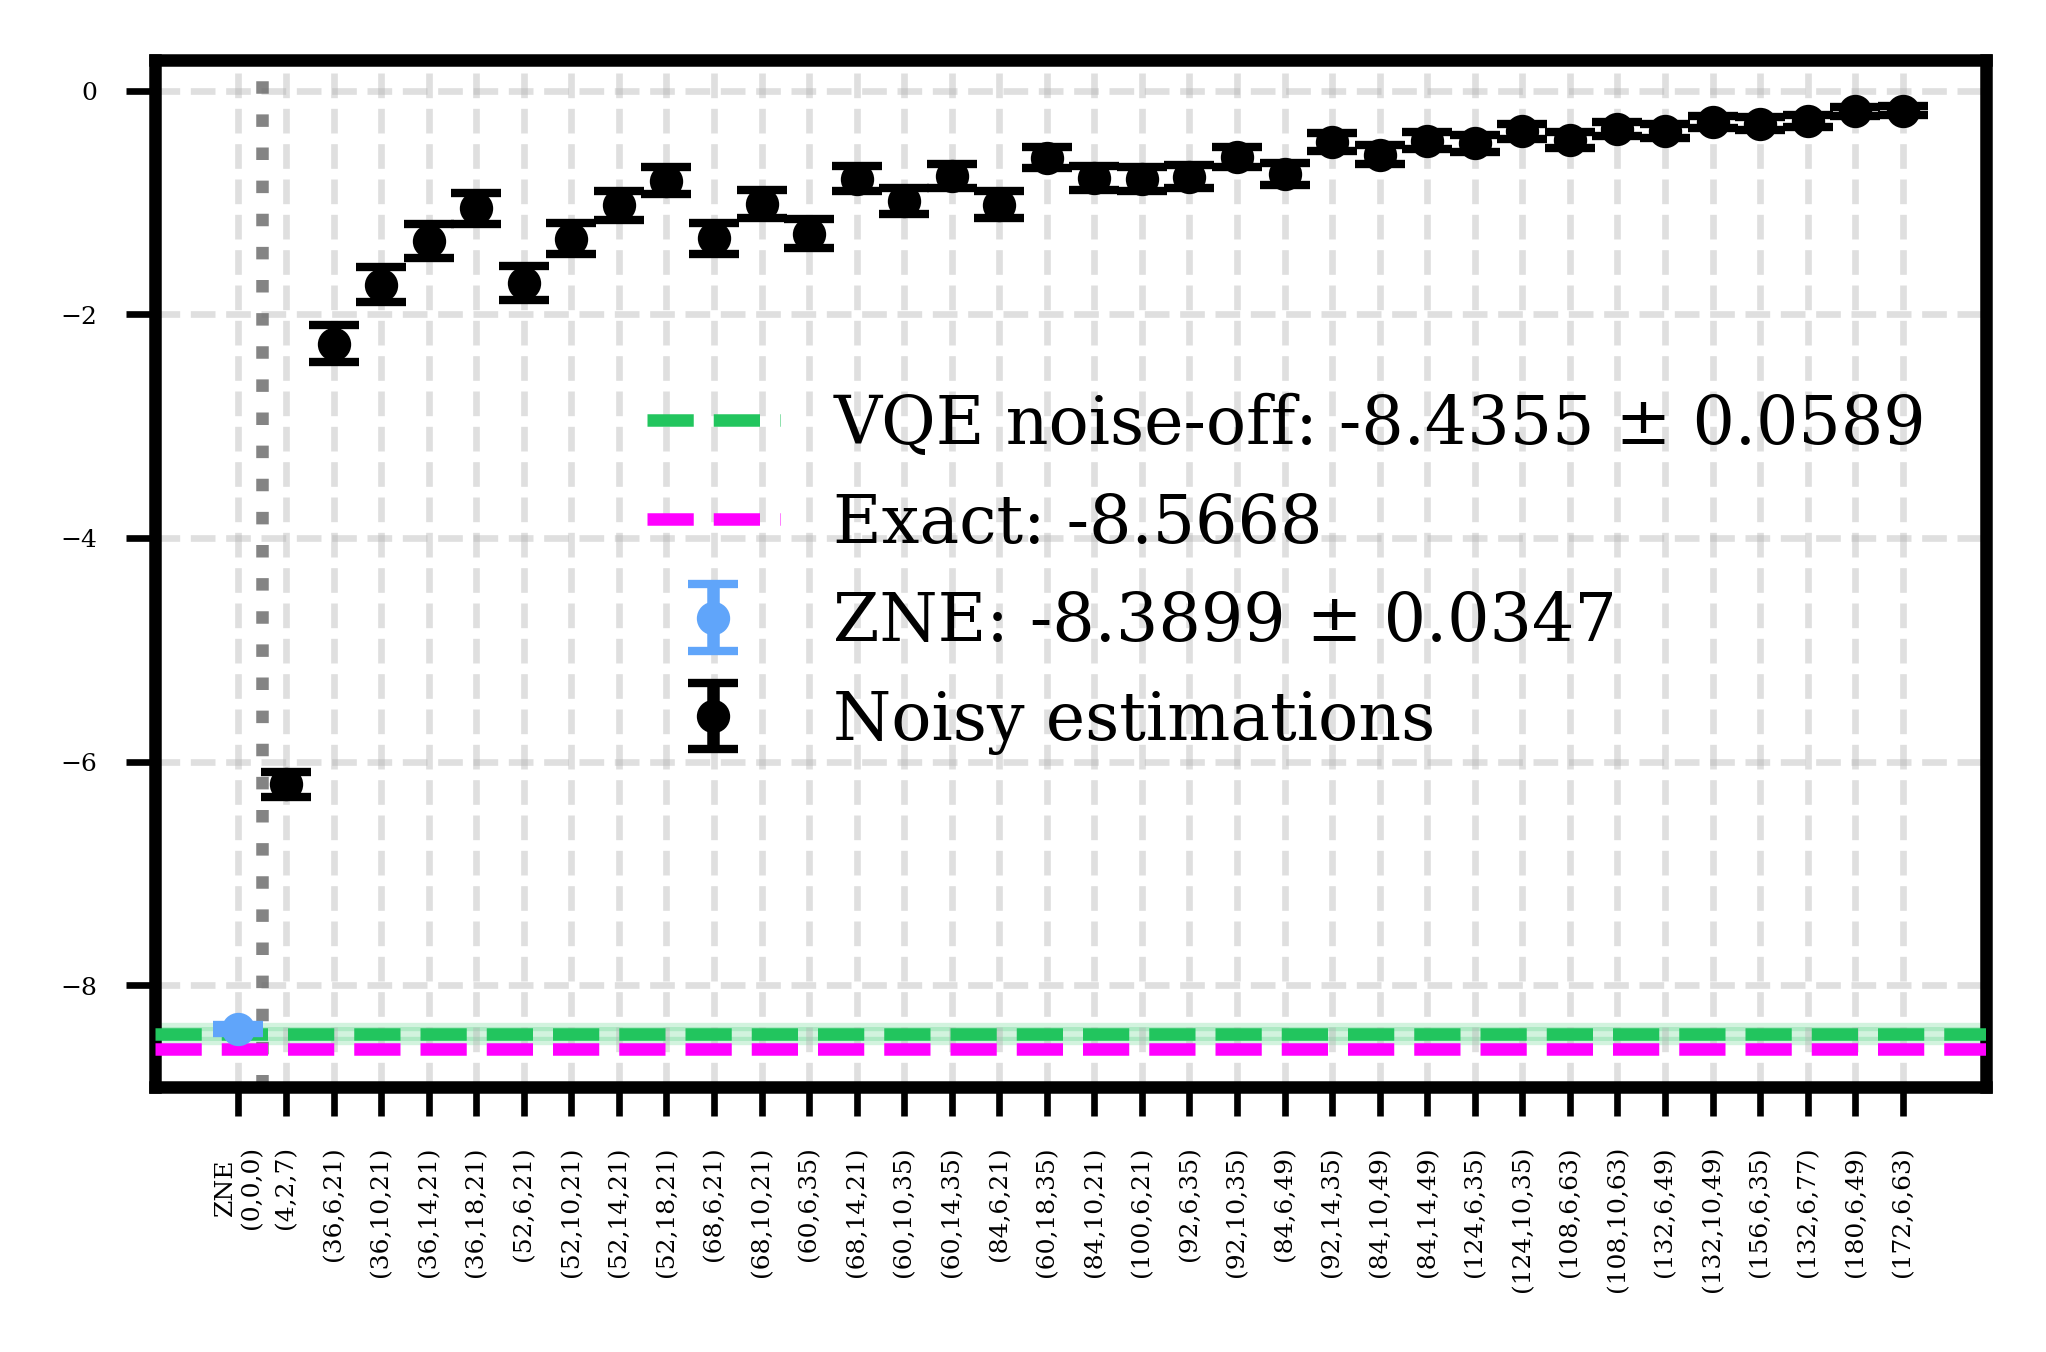

In [22]:
plot_zne_mul_var_single(
    data           = PROCESSED_SIM_DATA["ZNE-mul-var"]["muld4"],
    plot_colors    = {"zne": "#60a5fa", "noisy": "black",
                      "exact": "magenta", "noise_off": "#22c55e"},
    plot_file_name = "muld1_tmax20",
    output_dir     = OUTPUT_DIR,
    #plot_title     = "Multivariate ZNE",
    tick_fontsize  = 3,
    label_fontsize = 7,
    capsize  = 3,
    marker_size  = 3,
    border_width  = 1.5,
    legend_outside_plot = False,
    save_format    = ["png", "eps"],
    show_plot      = False,
    figsize               = FIG_SIZE_IEEE_DOUBLE,
    dpi                   = 600,
)

/home/arijit/Desktop/My Folder/indirect-zne/src/nbutils/master.py:1247: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


💾 Saved: reports/muld1_tmax20.png
💾 Saved: reports/muld1_tmax20.eps


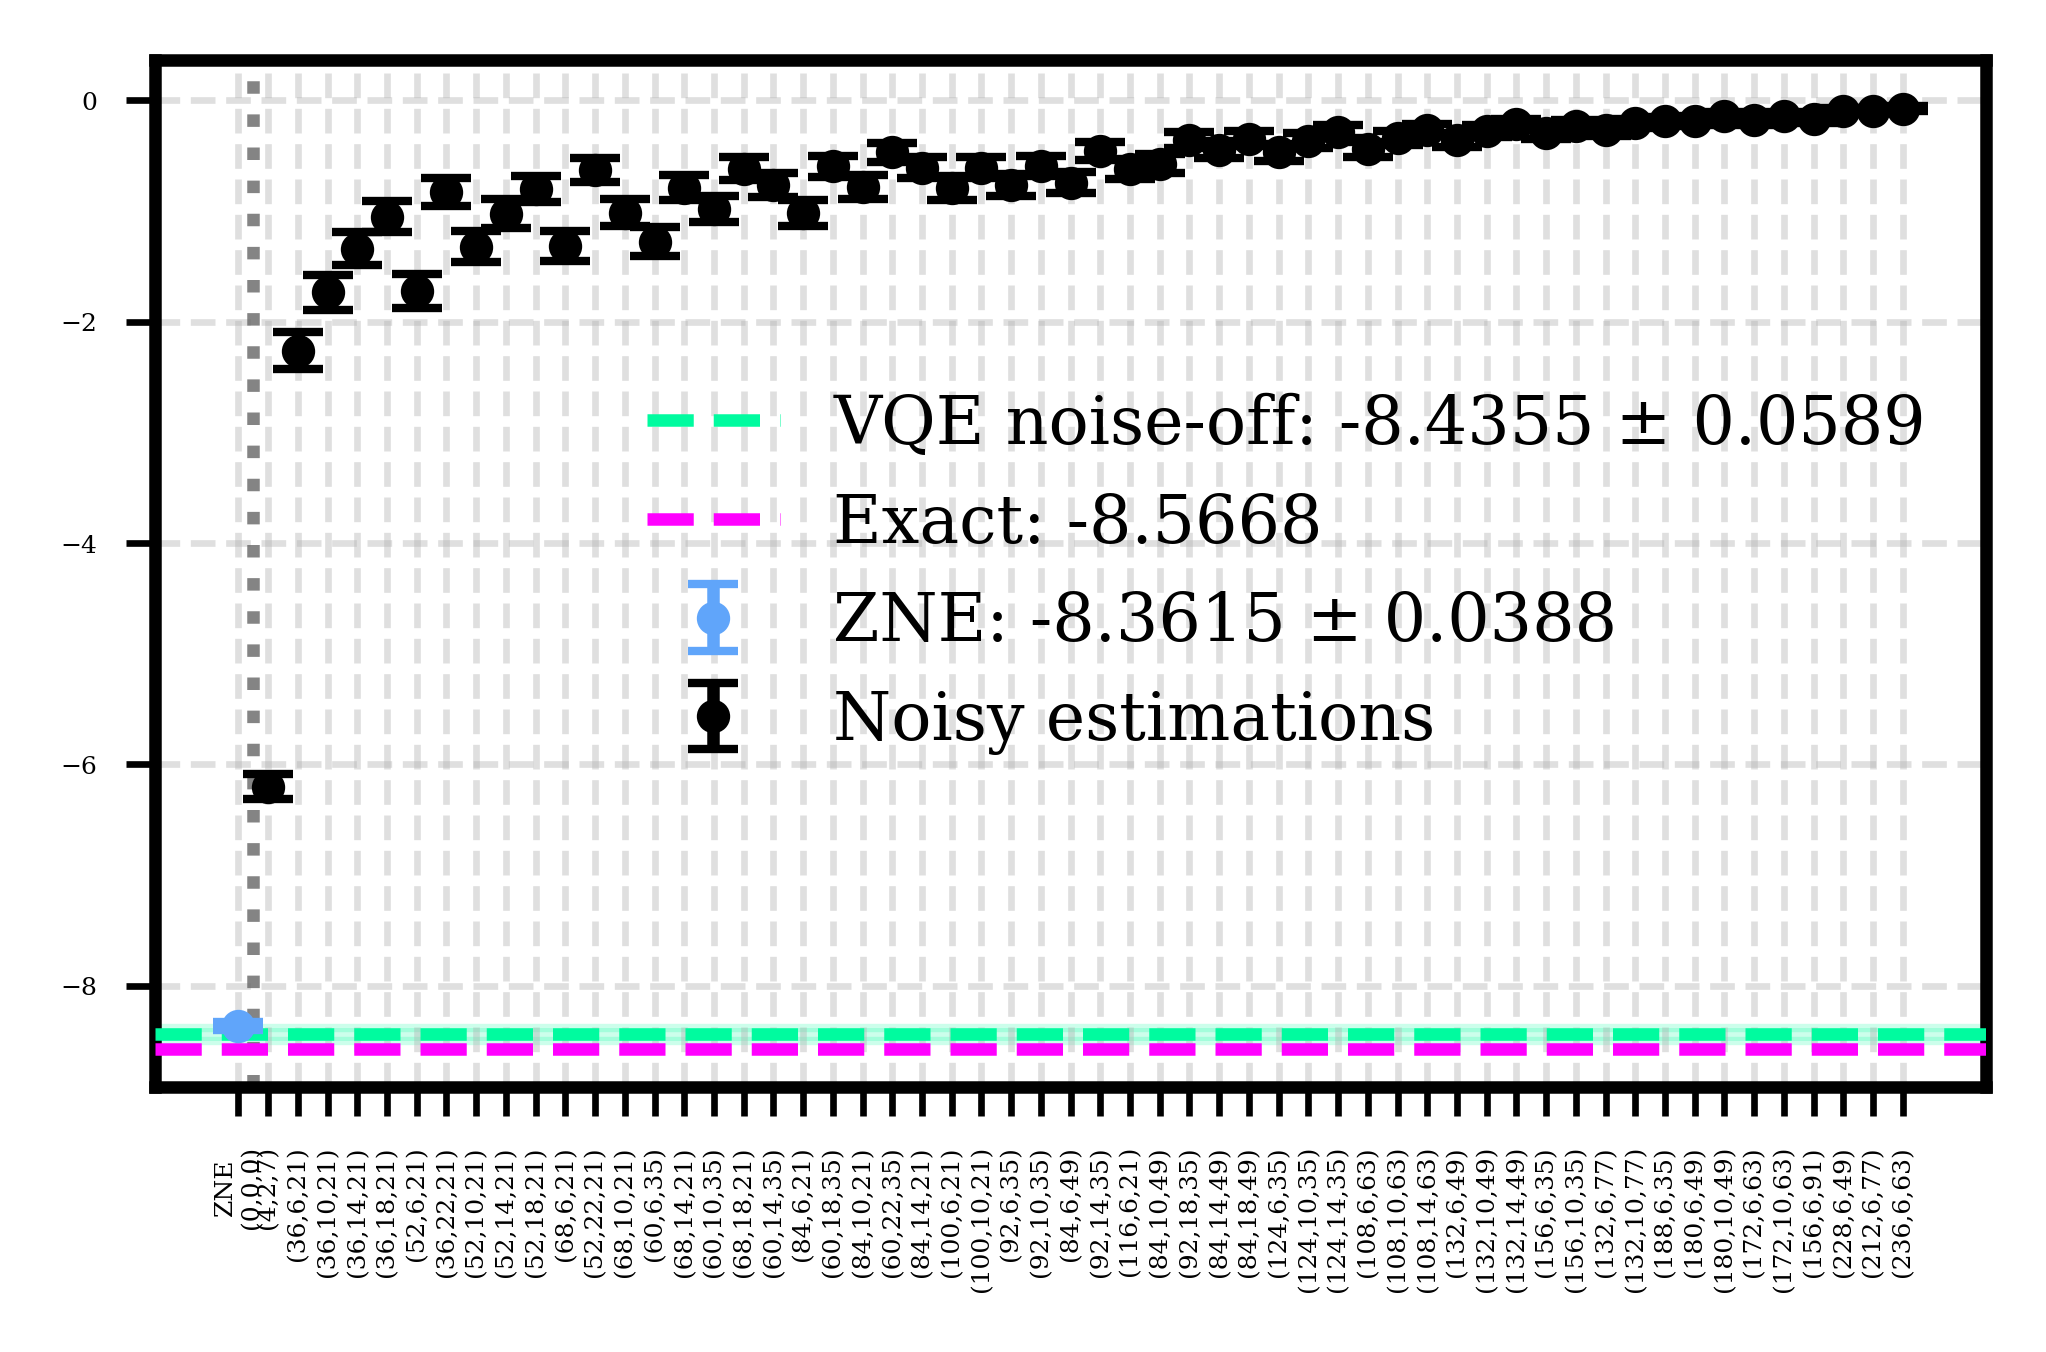

In [25]:
plot_zne_mul_var_single(
    data           = PROCESSED_SIM_DATA["ZNE-mul-var"]["muld5"],
    plot_colors    = {"zne": "#60a5fa", "noisy": "black",
                      "exact": "magenta", "noise_off": "#00fb9f"},
    plot_file_name = "muld1_tmax20",
    output_dir     = OUTPUT_DIR,
    #plot_title     = "Multivariate ZNE",
    tick_fontsize  = 3,
    label_fontsize = 7,
    capsize  = 3,
    marker_size  = 3,
    border_width  = 1.5,
    legend_outside_plot = False,
    save_format    = ["png", "eps"],
    show_plot      = False,
    figsize               = FIG_SIZE_IEEE_DOUBLE,
    dpi                   = 600,
)

✅ Saved: reports/multivariate_zne_vs_degree_IEEE_size.png


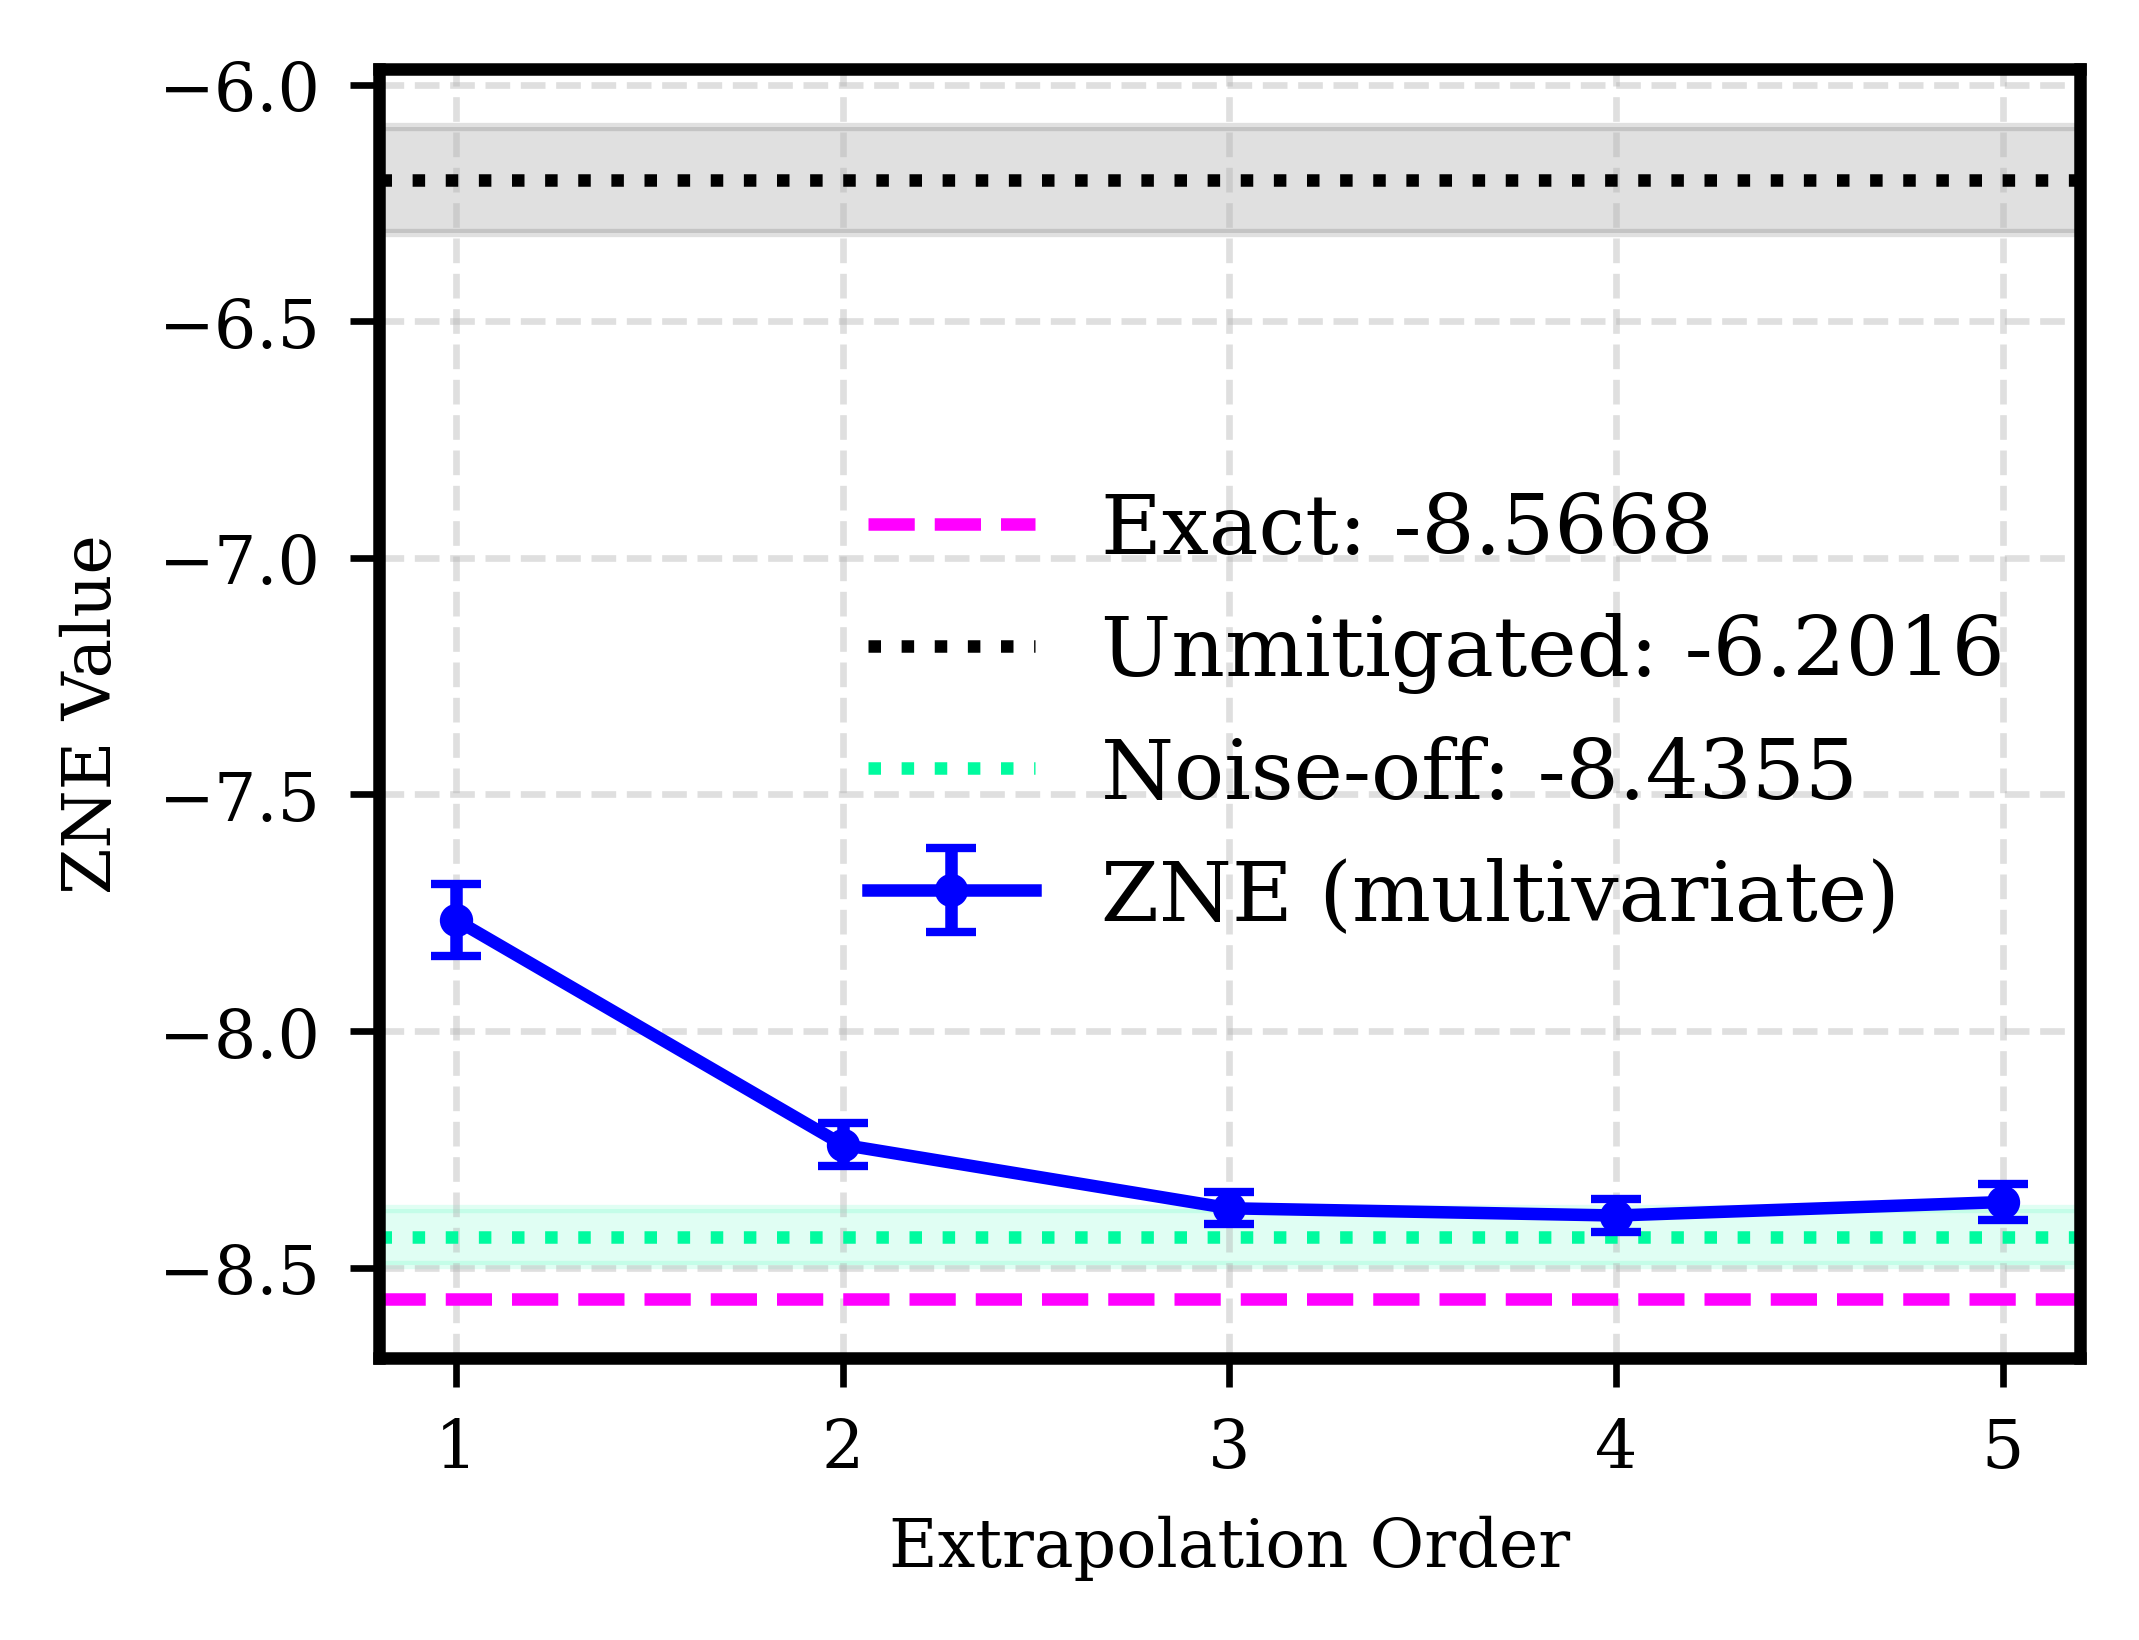

In [30]:
ricmul_plot_zne_vs_degree(
    processed_mul_var = PROCESSED_SIM_DATA["ZNE-mul-var"],
    plot_colors       = {"zne": "#0000ff", "noisy": "black",
                      "exact": "magenta", "noise_off": "#00fb9f", "unmitigated": "black"},
    plot_file_name    = "multivariate_zne_vs_degree_IEEE_size",
    output_dir        = OUTPUT_DIR,
    exact_sol         = -8.566772233505624,
    annotate_cost     = False,
    save_format       = "png",
    show_plot      = False,
    dpi                   = 600,
    figsize               = FIG_SIZE_IEEE_DOUBLE,
    tick_fontsize  = 8,
    label_fontsize = 8,
    capsize  = 3,
    marker_size  = 3,
    border_width  = 1.5,
)